<a href="https://colab.research.google.com/github/manojDOX/Water-Quality-Classification-ML/blob/main/Water_Quality_Classification_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-classification - Water Quality Classification**

##### **Project Type**    - Multi-classification
##### **Contribution**    - Individual
##### **Name -** **Manoj B**

# **Project Summary -**

**1. Project Objective**

This project aims to develop a machine learning model to classify water bodies in Maharashtra, India, into specific quality categories (Class A, B, C, E). The primary goal is to automate the assessment of water safety by analyzing physicochemical and biological parameters—such as pH, Dissolved Oxygen, and Coliform levels—sourced from the National Water Monitoring Programme (NWMP). This will enable rapid identification of water sources suitable for drinking, bathing, or irrigation.

**2. Business Problem & Value**

Deteriorating water quality and delayed identification of contamination pose severe risks to public health and environmental sustainability. This project addresses the challenge by leveraging data analytics to uncover pollution patterns and predict quality standards accurately. The key value lies in providing actionable insights for public health officials to prioritize interventions, monitor pollution trends like eutrophication or fecal contamination, and make informed decisions regarding water usage safety.

**3. Scope & Methodology**

Using a dataset of environmental features (e.g., Turbidity, Nitrate Nitrogen, BOD) and quality class labels, we will execute a complete data science workflow. This includes:

* **Exploratory Data Analysis (EDA):** To visualize correlations, detect outliers, and understand the distribution of water quality parameters.


* **Data Pre-processing:** To handle missing values, correct class imbalances, and engineer features relevant to environmental standards.


* **Model Development:** To train and validate multiple multiclass classification algorithms (e.g., Logistic Regression, Random Forest) to ensure high precision and recall.


* **Deployment (Optional):** To create an interactive Streamlit dashboard that allows users to input water metrics and receive instant quality classifications.



**4. Expected Deliverable**

The final deliverable will be a GitHub repository containing a robust analysis pipeline, trained model files, and a comprehensive report detailing model performance and key findings. This will be accompanied by an executive summary and presentation slides offering strategic recommendations for water quality monitoring and improvement.

# **GitHub Link-**

https://github.com/manojDOX/Water-Quality-Classification-ML/tree/main

# **Problem Statement**

The challenge is to classify water bodies in Maharashtra into specific quality categories (such as safe for drinking, bathing, or irrigation) based on their chemical and biological makeup. By analyzing parameters like pH, dissolved oxygen, and pollution levels, this project aims to build a machine learning model that automates water safety assessments to support public health decisions.

# **1. Know Your Data**

## Import Libraries

In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Selection & Evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Statistics
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Model Saving
import joblib


## Dataset Loading

In [2]:
import pandas as pd

# Direct links to Google Drive CSVs
url1 = "https://drive.google.com/uc?id=15PWGmojzt9yzAtC24Hoppuakf33EP7OC"
url2 = "https://drive.google.com/uc?id=1mp0_PrmbrfZtdVQxsl8Hqr_oQiahyaEL"
url3 = "https://drive.google.com/uc?id=1fSFAztPbZnrRdl3gFFaVgj3ItyRzkagU"

# Load each CSV as a DataFrame
df1 = pd.read_csv(url1, encoding="latin1")
df2 = pd.read_csv(url2, encoding="latin1")
df3 = pd.read_csv(url3, encoding="latin1")

# Optional: Print shapes to confirm
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print("df3 shape:", df3.shape)

df1 shape: (222, 54)
df2 shape: (222, 53)
df3 shape: (222, 54)


## Data First Look

In [3]:
df1.head()

,STN Code,Sampling Date,Month,Sampling Time,Stn Name,Type Water Body,Name Of Water Body,River Basin,District,State Name,...,Total Dissolved Solids,Total Fixed Solids,Total Suspended Solids,Phosphate,Boron,Potassium,Flouride,Remark,latitude,longitude
0,1312,09-04-2025,Sep,13:30:00,"Godavari river at Jaikwadi Dam, Village. Paith...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,448.0,404.0,15,0.4,0.5(BDL),2.94,0.77,NaN,19°29.263',75°22.272'
1,2158,09-04-2025,Sep,14:00:00,Godavari river at U/s of Paithan at Paithan in...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,459.0,414.0,14,0.5,0.55,3.01,0.42,NaN,19°30.887,75°22.457
2,2159,09-04-2025,Sep,14:30:00,Godavari river at D/s of Paithan at Pathegaon ...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,449.0,405.0,12,0.62,0.51,2.92,0.24,NaN,19°28.835,75°23.835
3,2160,09-04-2025,Sep,12:15:00,"Godavari river at U/s of Aurangabad Reservoir,...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,451.0,406.0,12,0.29,0.57,2.89,0.32,NaN,19°37.463,75°01.490
4,2161,09-03-2025,Sep,17:00:00,Godavari river at Jalna Intake water pump hous...,River,Godavari,Godavari,Jalna,Maharashtra,...,284.0,256.0,11,0.4,0.51,1.34,0.2(BDL),NaN,19°21.392,75°42.870


In [4]:
df2.head()

,STN Code,Sampling Date,Month,Sampling Time,Stn Name,Type Water Body,Name Of Water Body,River Basin,District,State Name,...,Sodium,Total Dissolved Solids,Total Fixed Solids,Total Suspended Solids,Phosphate,Boron,Potassium,Flouride,latitude,longitude
0,1312,07-03-2025,Jul,14:45:00,"Godavari river at Jaikwadi Dam, Village. Paith...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,59.8,496.0,447.0,10(BDL),0.82,0.51,3.35,0.68,19°29.263',75°22.272'
1,2158,07-03-2025,Jul,14:00:00,Godavari river at U/s of Paithan at Paithan in...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,63.43,493.0,444.0,10(BDL),0.98,0.54,3.3,0.97,19°30.887,75°22.457
2,2159,07-03-2025,Jul,16:00:00,Godavari river at D/s of Paithan at Pathegaon ...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,59.78,509.0,459.0,11,0.9,0.53,3.36,0.55,19°28.835,75°23.835
3,2160,07-03-2025,Jul,13:00:00,"Godavari river at U/s of Aurangabad Reservoir,...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,61.75,515.0,464.0,11,0.87,0.56,3.43,0.67,19°37.463,75°01.490
4,2161,07-09-2025,Jul,14:15:00,Godavari river at Jalna Intake water pump hous...,River,Godavari,Godavari,Jalna,Maharashtra,...,111.8,806.0,726.0,19,0.8,0.56,5.83,0.56,19°21.392,75°42.870


In [5]:
df3.head()

,STN Code,Sampling Date,Month,Sampling Time,Stn Name,Type Water Body,Name Of Water Body,River Basin,District,State Name,...,Total Dissolved Solids,Total Fixed Solids,Total Suspended Solids,Phosphate,Boron,Potassium,Flouride,Remark,latitude,longitude
0,1312,08-05-2025,Aug,16:30:00,"Godavari river at Jaikwadi Dam, Village. Paith...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,497.0,448.0,10(BDL),0.78,0.58,2.88,0.5,NaN,19°29.263',75°22.272'
1,2158,08-05-2025,Aug,16:00:00,Godavari river at U/s of Paithan at Paithan in...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,489.0,441.0,11,0.71,0.61,3.14,0.41,NaN,19°30.887,75°22.457
2,2159,08-05-2025,Aug,17:15:00,Godavari river at D/s of Paithan at Pathegaon ...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,491.0,442.0,11,0.76,0.56,3.16,0.45,NaN,19°28.835,75°23.835
3,2160,08-05-2025,Aug,15:00:00,"Godavari river at U/s of Aurangabad Reservoir,...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,479.0,612.0,10(BDL),1.47,0.55,3.13,0.6,NaN,19°37.463,75°01.490
4,2161,08-04-2025,Aug,15:30:00,Godavari river at Jalna Intake water pump hous...,River,Godavari,Godavari,Jalna,Maharashtra,...,765.0,689.0,12,0.33,0.56,4.57,0.49,NaN,19°21.392,75°42.870


## Preparing main DataFrame

In [6]:
'''
Purpose:
    Combine multiple monthly DataFrames into a single DataFrame while aligning all columns
    and filling missing values with NaN.

Args:
    df1 (DataFrame): First month data
    df2 (DataFrame): Second month data
    df3 (DataFrame): Third month data

Return:
    combined_df (DataFrame): Merged DataFrame containing all columns from all inputs
'''
def combine_monthly_dfs(df1, df2, df3):
    import pandas as pd

    all_columns = set(df1.columns) | set(df2.columns) | set(df3.columns)

    df1_aligned = df1.reindex(columns=all_columns)
    df2_aligned = df2.reindex(columns=all_columns)
    df3_aligned = df3.reindex(columns=all_columns)

    combined_df = pd.concat([df1_aligned, df2_aligned, df3_aligned], ignore_index=True)

    return combined_df


combined_df = combine_monthly_dfs(df1, df2, df3)


In [7]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Weather                         645 non-null    object 
 1   Sampling Time                   666 non-null    object 
 2   Boron                           567 non-null    object 
 3   Dissolved O2                    645 non-null    object 
 4   Nitrate N                       643 non-null    object 
 5   Nitrite N                       0 non-null      float64
 6   Total Fixed Solids              645 non-null    float64
 7   Use Based Class                 645 non-null    object 
 8   Amonia N                        641 non-null    float64
 9   Magnesium CaCo3                 645 non-null    float64
 10  River Basin                     594 non-null    object 
 11  Chlorides                       645 non-null    object 
 12  Frequency                       666 

## Columns Info

1. **Phosphate** – Amount of phosphate nutrients present in water
2. **Floating Matter** – Presence of visible floating particles on water surface
3. **Nitrite N** – Nitrite nitrogen concentration (indicator of nitrogen pollution)
4. **Total Kjeldahl N** – Total organic nitrogen and ammonia nitrogen
5. **Temperature** – Water temperature at sampling time
6. **Visibility Effluent Discharge** – Whether effluent discharge is visible at site
7. **Fecal Streptococci** – Indicator bacteria showing fecal contamination
8. **Magnesium CaCo3** – Magnesium hardness expressed as CaCO3
9. **pH** – Acidity or alkalinity of water
10. **Major Polluting Sources** – Main pollution source near sampling location
11. **Calcium CaCo3** – Calcium hardness expressed as CaCO3
12. **Nitrate N** – Nitrate nitrogen concentration (fertilizer runoff indicator)
13. **Turbidity** – Cloudiness of water due to suspended particles
14. **Month** – Month when sample was collected
15. **Sampling Time** – Time of day sample was collected
16. **latitude** – Geographic latitude coordinate
17. **Name Of Water Body** – Name of river/lake/stream etc.
18. **Type Water Body** – Category of water body (River, Lake, Creek, etc.)
19. **Color** – Visual color of water
20. **Phenophelene Alkanity** – Alkalinity measured using phenolphthalein indicator
21. **Sulphate** – Sulphate ion concentration
22. **Dissolved O2** – Dissolved oxygen available for aquatic life
23. **Remark** – Additional comments about sample
24. **Mon Agency** – Monitoring agency name
25. **Use Based Class** – Water quality classification based on intended use
26. **Potassium** – Potassium ion concentration
27. **Sodium** – Sodium ion concentration
28. **Stn Name** – Monitoring station name
29. **Sampling Date** – Date of sample collection
30. **Flow** – Water flow rate
31. **Total Coliform** – Total coliform bacteria count
32. **Approx Depth** – Approximate water depth at site
33. **Fecal Coliform** – Fecal coliform bacteria count
34. **Use of Water in Down Stream** – How downstream water is used
35. **BOD** – Biochemical Oxygen Demand (organic pollution indicator)
36. **Boron** – Boron concentration
37. **District** – Administrative district name
38. **longitude** – Geographic longitude coordinate
39. **River Basin** – Basin where river belongs
40. **State Name** – State of sampling location
41. **Frequency** – Sampling frequency
42. **Total Alkalinity** – Water’s capacity to neutralize acids
43. **COD** – Chemical Oxygen Demand (total organic matter)
44. **Conductivity** – Ability of water to conduct electricity (salinity)
45. **Odor** – Smell of water
46. **Human Activities** – Human activities near sampling site
47. **Weather** – Weather condition during sampling
48. **STN Code** – Station identification code
49. **Amonia N** – Ammonia nitrogen concentration
50. **Hardness CaCo3** – Total hardness expressed as CaCO3
51. **Total Dissolved Solids** – Total dissolved minerals and salts
52. **Flouride** – Fluoride concentration
53. **Chlorides** – Chloride ion concentration
54. **Total Suspended Solids** – Suspended particles in water
55. **Total Fixed Solids** – Inorganic solids remaining after heating

In [8]:
'''
Purpose:
    Print all column names in numbered order.

Args:
    df (DataFrame): Input DataFrame

Return:
    None
'''
def print_numbered_columns(df):
    for i, col in enumerate(df.columns, start=1):
        print(f"{i}. {col}")


print_numbered_columns(combined_df)


1. Weather
2. Sampling Time
3. Boron
4. Dissolved O2
5. Nitrate N
6. Nitrite N
7. Total Fixed Solids
8. Use Based Class
9. Amonia N
10. Magnesium CaCo3
11. River Basin
12. Chlorides
13. Frequency
14. Color
15. Total Suspended Solids
16. Approx Depth
17. Name Of Water Body
18.  Visibility Effluent Discharge
19. Phenophelene Alkanity
20. Odor
21. Stn Name
22. Human Activities
23. Potassium
24. Type Water Body
25. Temperature
26. Total Kjeldahl N
27. State Name
28. Hardness CaCo3
29. Sulphate
30. Phosphate
31. Flow
32. Total Coliform
33. Total Dissolved Solids
34. Sodium
35. Calcium CaCo3
36. Month
37. Major Polluting Sources
38. Sampling Date
39. STN Code
40. latitude
41. Floating Matter
42. Total Alkalinity
43. Flouride
44. Remark
45. Fecal Streptococci
46. longitude
47. District
48. pH
49. COD
50. Conductivity
51. Fecal Coliform
52. Mon Agency
53.  Use of Water in Down Stream
54. BOD
55. Turbidity


## Data Wrangling

### Mising Values and Operation on values

In [9]:
'''
Purpose:
    Remove rows where the specified column contains the value "No Information".

Args:
    df (DataFrame): Input DataFrame
    column (str): Column name to check

Return:
    updated_df (DataFrame): DataFrame after removing matching rows
'''
def remove_no_information_rows(df, column):
    updated_df = df[df[column] != "No Information"]
    return updated_df


combined_df = remove_no_information_rows(combined_df, "Use Based Class")


In [10]:
'''
Purpose:
    Print unique values for each column in the given DataFrame.

Args:
    df (DataFrame): Input DataFrame

Return:
    None
'''
def print_unique_values_per_column(df):
    for col in df.columns:
        print(f"\nColumn: {col}")
        print(df[col].dropna().unique())


print_unique_values_per_column(combined_df)



Column: Weather
['Clear' 'Cloudy' 'Raining']

Column: Sampling Time
['13:30:00' '14:00:00' '14:30:00' '12:15:00' '17:00:00' '15:00:00'
 '08:00:00' '07:30:00' '11:30:00' '10:15:00' '11:15:00' '09:30:00'
 '12:00:00' '04:00:00' '03:15:00' '11:00:00' '18:45:00' '11:25:00'
 '17:30:00' '12:30:00' '07:55:00' '10:35:00' '11:35:00' '13:25:00'
 '13:00:00' '12:25:00' '12:05:00' '18:35:00' '13:35:00' '14:35:00'
 '15:10:00' '12:50:00' '13:15:00' '12:20:00' '10:30:00' '10:00:00'
 '13:55:00' '11:20:00' '02:05:00' '04:10:00' '03:00:00' '03:20:00'
 '03:45:00' '04:30:00' '04:45:00' '05:00:00' '09:45:00' '12:45:00'
 '13:50:00' '10:50:00' '14:06:00' '13:07:00' '04:34:00' '04:33:00'
 '12:10:00' '15:25:00' '16:20:00' '15:05:00' '14:25:00' '14:15:00'
 '12:35:00' '17:05:00' '17:10:00' '17:25:00' '19:00:00' '18:00:00'
 '16:00:00' '14:45:00' '04:25:00' '10:45:00' '09:40:00' '10:40:00'
 '13:20:00' '13:45:00' '14:10:00' '16:05:00' '17:15:00' '16:30:00'
 '05:50:00' '05:30:00' '09:00:00' '17:45:00' '18:15:00' '11:

In [11]:
'''
Purpose:
    Print each column name with its missing value percentage in aligned format.

Args:
    df (DataFrame): Input DataFrame

Return:
    None
'''
def print_missing_percentage(df):
    total_rows = len(df)

    for col in df.columns:
        missing_percent = (df[col].isna().sum() / total_rows) * 100
        print(f"{col:<35} {missing_percent:>7.2f}%")


print_missing_percentage(combined_df)


Weather                                3.95%
Sampling Time                          0.00%
Boron                                 13.91%
Dissolved O2                           3.95%
Nitrate N                              4.32%
Nitrite N                            100.00%
Total Fixed Solids                     3.95%
Use Based Class                        3.95%
Amonia N                               4.70%
Magnesium CaCo3                        3.95%
River Basin                           11.47%
Chlorides                              3.95%
Frequency                              0.00%
Color                                  3.95%
Total Suspended Solids                 3.95%
Approx Depth                           3.95%
Name Of Water Body                    10.34%
 Visibility Effluent Discharge        37.22%
Phenophelene Alkanity                  4.70%
Odor                                  80.26%
Stn Name                               0.00%
Human Activities                       3.95%
Potassium 

Remark : Null refer to no reason and values are intact but if Non Null then that means the water bodies are dryed out and not able to perform any calibration

In [12]:
'''
Purpose:
    Remove rows where the Remark column has non-null values and keep only rows
    where Remark is null.

Args:
    df (DataFrame): Input DataFrame

Return:
    cleaned_df (DataFrame): DataFrame containing only rows with null Remark
'''
def remove_non_null_remark_rows(df):
    cleaned_df = df[df["Remark"].isna()]

    return cleaned_df


combined_df = remove_non_null_remark_rows(combined_df)
print_missing_percentage(combined_df)

Weather                                2.48%
Sampling Time                          0.00%
Boron                                 12.60%
Dissolved O2                           2.48%
Nitrate N                              2.86%
Nitrite N                            100.00%
Total Fixed Solids                     2.48%
Use Based Class                        2.48%
Amonia N                               3.24%
Magnesium CaCo3                        2.48%
River Basin                           11.64%
Chlorides                              2.48%
Frequency                              0.00%
Color                                  2.48%
Total Suspended Solids                 2.48%
Approx Depth                           2.48%
Name Of Water Body                    10.50%
 Visibility Effluent Discharge        36.26%
Phenophelene Alkanity                  3.24%
Odor                                  79.96%
Stn Name                               0.00%
Human Activities                       2.48%
Potassium 

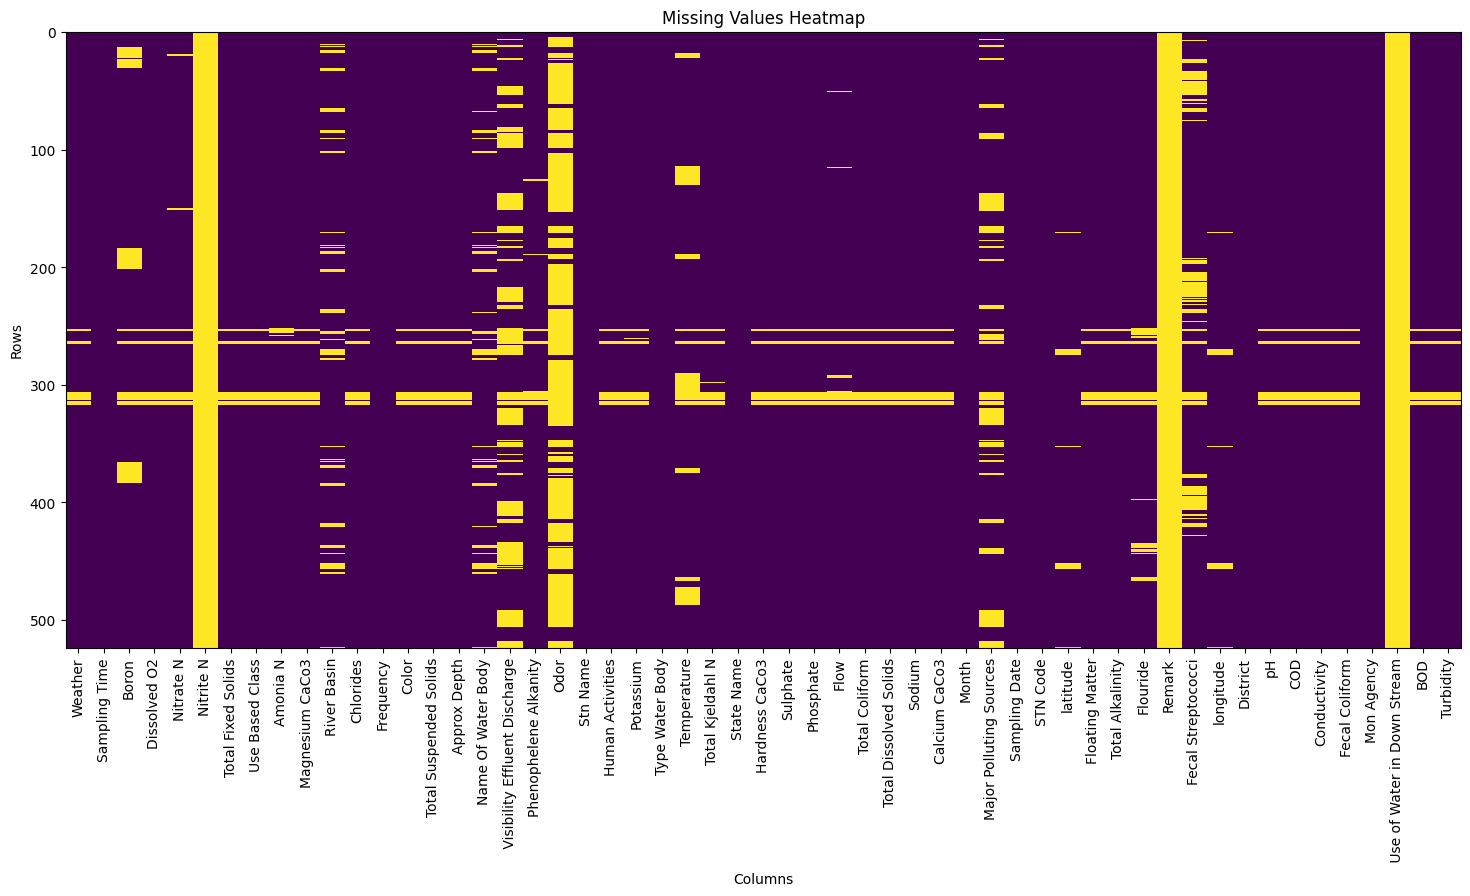

In [13]:
'''
Purpose:
    Plot a heatmap showing missing values with clear cell boundaries,
    rows representing records and columns representing features.

Args:
    df (DataFrame): Input DataFrame

Return:
    None
'''
def plot_missing_values_heatmap(df):
    import matplotlib.pyplot as plt
    import numpy as np

    missing_matrix = df.isna().astype(int)

    plt.figure(figsize=(18, 8))
    plt.imshow(missing_matrix, aspect="auto", interpolation="nearest")
    plt.xticks(range(len(df.columns)), df.columns, rotation=90)
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.title("Missing Values Heatmap")
    plt.grid(False)
    plt.show()


plot_missing_values_heatmap(combined_df)


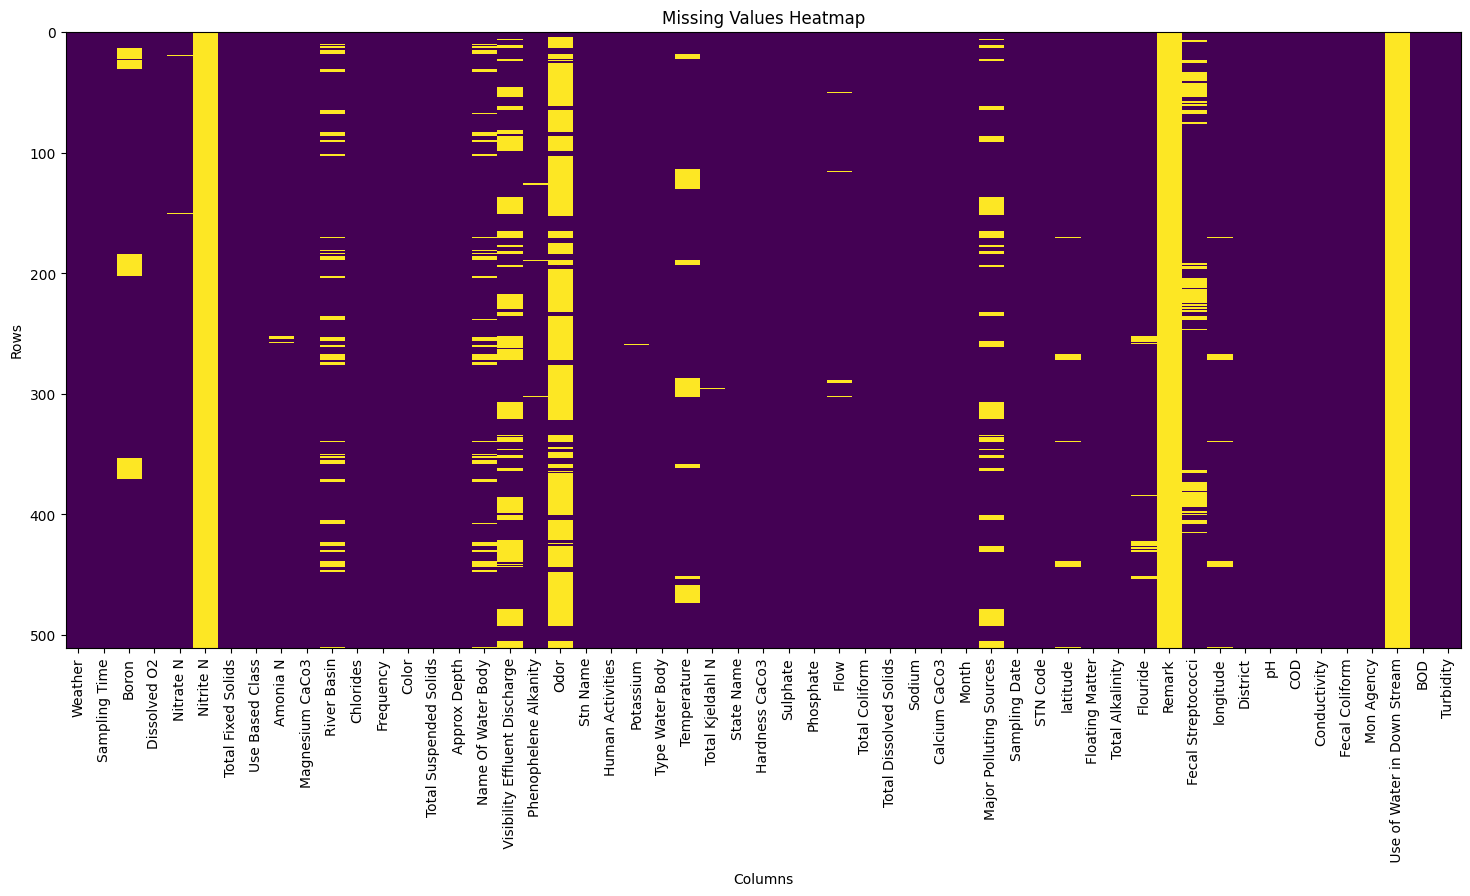

In [14]:
'''
Purpose:
    Remove rows that contain null values in any of the specified columns.

Args:
    df (DataFrame): Input DataFrame
    columns (list): List of column names to check for null values

Return:
    cleaned_df (DataFrame): DataFrame with rows removed where null exists in given columns
'''
def remove_rows_with_nulls_in_columns(df, columns):
    cleaned_df = df.dropna(subset=columns)
    return cleaned_df


combined_df = remove_rows_with_nulls_in_columns(combined_df, ["Calcium CaCo3"])
plot_missing_values_heatmap(combined_df)


Following columns has been dropped:
Remark, Nitrite N,  Use of Water in Down Stream, Odor


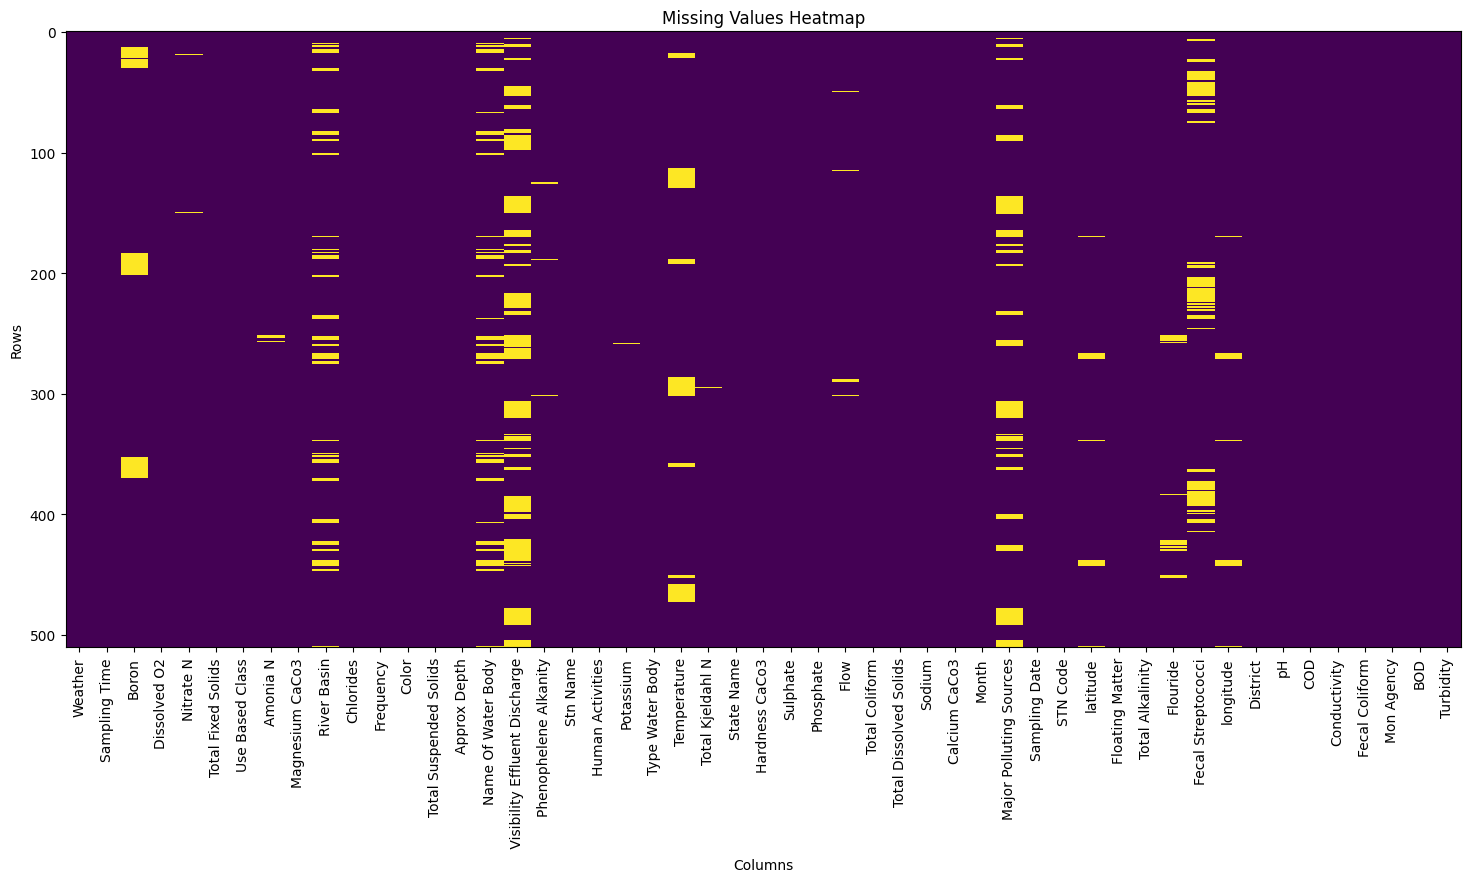

In [15]:
'''
Purpose:
    Drop specified columns from the DataFrame.

Args:
    df (DataFrame): Input DataFrame
    columns (list): List of column names to be dropped

Return:
    updated_df (DataFrame): DataFrame after dropping given columns
'''
def drop_columns(df, columns):
    updated_df = df.drop(columns=columns, errors="ignore")
    print("Following columns has been dropped:")
    print(', '.join(columns))
    return updated_df


combined_df = drop_columns(combined_df, ["Remark", "Nitrite N", " Use of Water in Down Stream", "Odor"])
plot_missing_values_heatmap(combined_df)

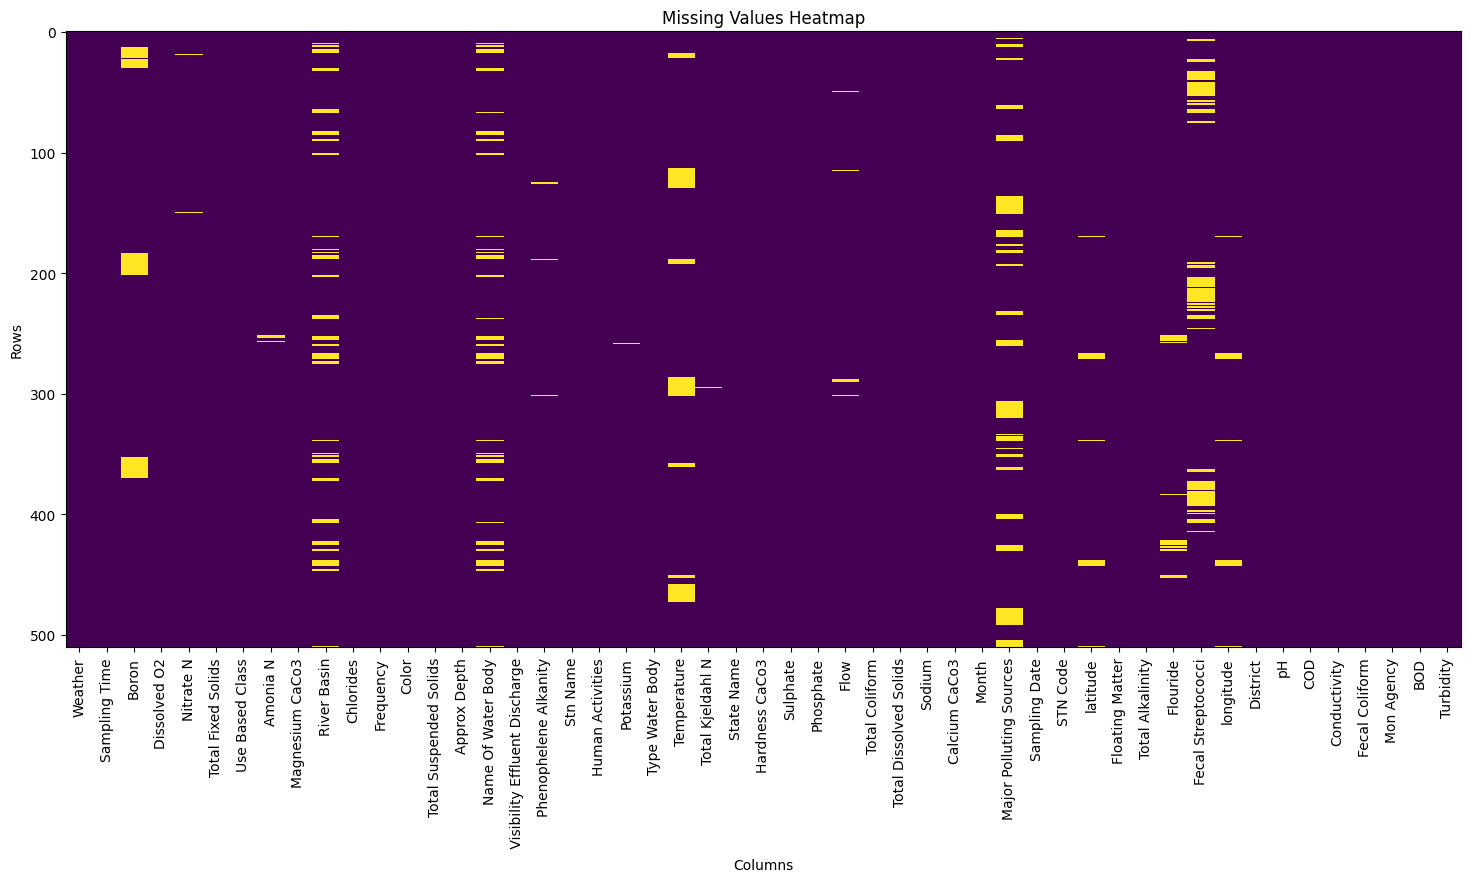

In [16]:
'''
Purpose:
    Replace null values in a specified column with a given value.

Args:
    df (DataFrame): Input DataFrame
    column (str): Column name where null values should be filled
    value: Value to replace null entries

Return:
    updated_df (DataFrame): DataFrame with nulls replaced in given column
'''
def fill_null_with_value(df, column, value):
    updated_df = df.copy()
    updated_df[column] = updated_df[column].fillna(value)
    return updated_df


combined_df = fill_null_with_value(combined_df, " Visibility Effluent Discharge", "No Discharge")
plot_missing_values_heatmap(combined_df)

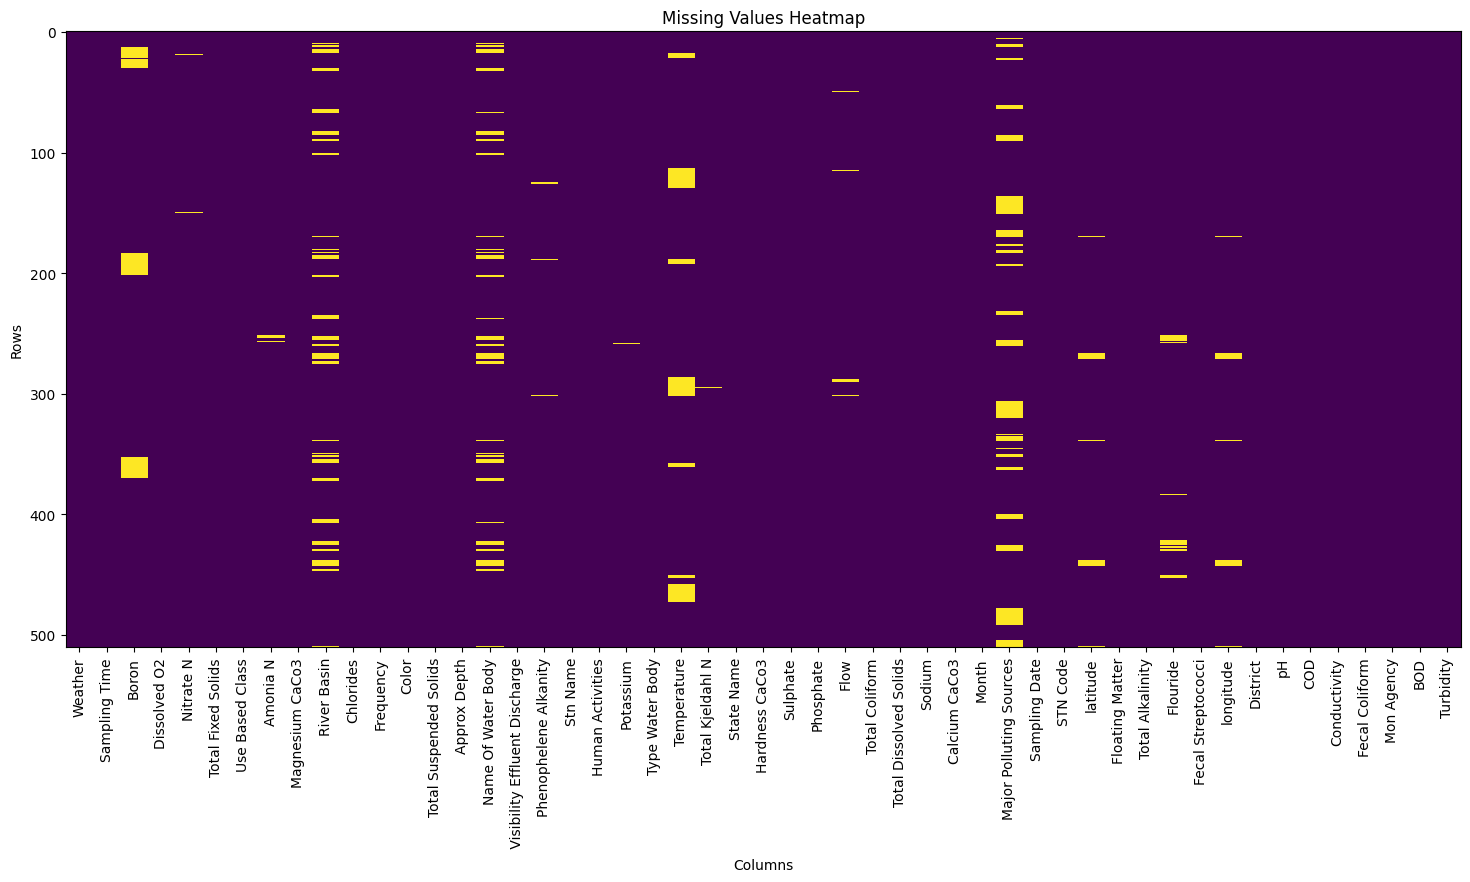

In [17]:
'''
Purpose:
    Replace multiple specific values in a given column using a mapping dictionary
    and fill null values with a specified value.

Args:
    df (DataFrame): Input DataFrame
    column (str): Column name where replacements should occur
    replace_dict (dict): Dictionary mapping old values to new values
    fill_value: Value used to replace null entries

Return:
    updated_df (DataFrame): DataFrame with values replaced and nulls filled
'''
def replace_values_and_fill_null(df, column, replace_dict, fill_value):
    updated_df = df.copy()
    updated_df[column] = updated_df[column].replace(replace_dict)
    updated_df[column] = updated_df[column].fillna(fill_value)
    return updated_df


combined_df = replace_values_and_fill_null(
    combined_df,
    "Fecal Streptococci",
    {"1.8(BDL)": "1.8", "BDL": "1.5"},
    "0"
)

plot_missing_values_heatmap(combined_df)

In [18]:
combined_df['Temperature'].unique()

array([28. , 25. , 24. , 19. , 18. , 32. , 22. , 23. ,  nan, 26. , 29. ,
       30. , 27. , 20. , 16. , 21. , 27.5, 26.5, 17. , 31. ])

In [19]:
combined_df['Temperature'].mean()

np.float64(25.292873051224944)

In [20]:
combined_df = replace_values_and_fill_null(
    combined_df,
    "Temperature",
    {},
    combined_df['Temperature'].mean()
)

In [21]:
'''
Purpose:
    Convert all values of a specified column to float type.

Args:
    df (DataFrame): Input DataFrame
    column (str): Column name to be converted to float

Return:
    updated_df (DataFrame): DataFrame with column converted to float
'''
def convert_column_to_float(df, column):
    updated_df = df.copy()
    updated_df[column] = updated_df[column].astype(float)
    return updated_df


combined_df = convert_column_to_float(combined_df, "Temperature")


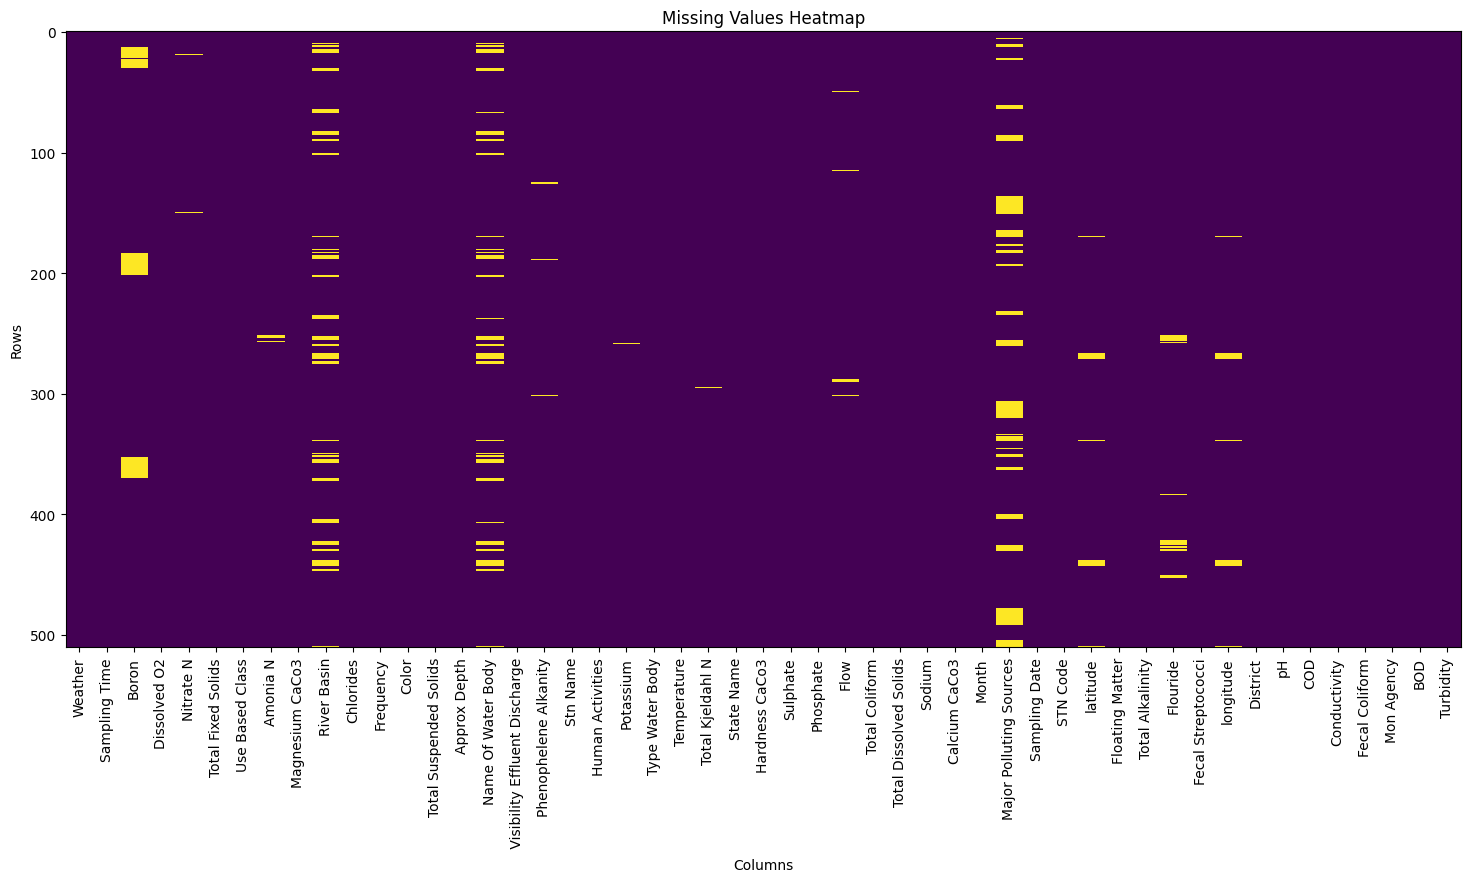

In [22]:
plot_missing_values_heatmap(combined_df)

In [23]:
# '''
# Purpose:
#     Iterate through all columns, display unique values, ask user whether to convert
#     column to float, convert numeric values while keeping string values unchanged,
#     and record all actions performed.

# Args:
#     df (DataFrame): Input DataFrame

# Return:
#     updated_df (DataFrame): Updated DataFrame after user-driven conversions
# '''
# def interactive_column_processing(df):
#     import pandas as pd

#     updated_df = df.copy()
#     actions_log = {}

#     for col in updated_df.columns:
#         print("\nColumn:", col)
#         print("Unique Values:", updated_df[col].dropna().unique())

#         choice = input("Convert this column to float? (yes/no): ").strip().lower()

#         if choice == "yes":
#             temp = pd.to_numeric(updated_df[col], errors="coerce")
#             updated_df[col] = temp.combine_first(updated_df[col])
#             actions_log[col] = "Converted numeric values to float (strings kept)"
#         else:
#             actions_log[col] = "Skipped"

#     print("\nSummary of Actions:")
#     for col, action in actions_log.items():
#         print(f"{col} -> {action}")

#     return updated_df


# combined_df = interactive_column_processing(combined_df)


In [24]:
# '''
# Purpose:
#     Iterate through columns, display unique values, ask user to skip or operate.
#     If operate, detect all unique values containing substring "BDL", ask user
#     replacement for each, apply replacements, and record all actions performed.
#     Finally print a detailed summary for future function creation.

# Args:
#     df (DataFrame): Input DataFrame

# Return:
#     updated_df (DataFrame): DataFrame after applying BDL replacements
# '''
# def interactive_bdl_processing(df):
#     updated_df = df.copy()
#     actions_log = {}

#     for col in updated_df.columns:
#         print("\nColumn:", col)
#         uniques = updated_df[col].dropna().unique()
#         print("Unique Values:", uniques)

#         choice = input("Skip or Operate? (skip: s/operate: o): ").strip().lower()

#         if choice == "o":
#             bdl_values = [val for val in uniques if "BDL" in str(val)]
#             col_actions = {}

#             for val in bdl_values:
#                 new_val = input(f'Value "{val}" contains BDL. Enter replacement: ')
#                 updated_df[col] = updated_df[col].replace(val, new_val)
#                 col_actions[val] = new_val

#             if col_actions:
#                 actions_log[col] = col_actions
#             else:
#                 actions_log[col] = "No BDL values found"
#         else:
#             actions_log[col] = "Skipped"

#     print("\nSummary of Actions:")
#     for col, action in actions_log.items():
#         print(f"{col} -> {action}")

#     return updated_df


# combined_df = interactive_bdl_processing(combined_df)


In [25]:
'''
Purpose:
    Apply predefined BDL substring replacement mappings on columns based on
    previously recorded user decisions and update the DataFrame automatically.

Args:
    df (DataFrame): Input DataFrame

Return:
    updated_df (DataFrame): DataFrame after applying BDL replacements
'''
def apply_bdl_replacements(df):
    updated_df = df.copy()

    bdl_mappings = {
        "Phosphate": {"0.2(BDL)": "0.2"},
        "Total Kjeldahl N": {"1.5(BDL)": "1.5"},
        "Nitrate N": {"0.3(BDL)": "0.3"},
        "Turbidity": {"1(BDL)": "1"},
        "Phenophelene Alkanity": {"5(BDL)": "5", "BDL": "2.5"},
        "Sulphate": {"5(BDL)": "5", "BDL": "2.5"},
        "Dissolved O2": {"0.3(BDL)": "0.3"},
        "Potassium": {"1(BDL)": "1", "BDL": "0.5"},
        "Sodium": {"5(BDL)": "5"},
        "Total Coliform": {"1.8(BDL)": "1.8"},
        "Fecal Coliform": {"1.8(BDL)": "1.8"},
        "BOD": {"1(BDL)": "1"},
        "Boron": {"0.5(BDL)": "0.5"},
        "Total Alkalinity": {"20(BDL)": "20"},
        "Flouride": {"0.2(BDL)": "0.2", "BDL": "0.1"},
        "Chlorides": {"5(BDL)": "5"},
        "Total Suspended Solids": {"10(BDL)": "10", "BDL": "5"}
    }

    actions_log = {}

    for col, mapping in bdl_mappings.items():
        if col in updated_df.columns:
            updated_df[col] = updated_df[col].replace(mapping)
            actions_log[col] = mapping

    print("\nSummary of Actions:")
    for col, action in actions_log.items():
        print(f"{col} -> {action}")

    return updated_df


combined_df = apply_bdl_replacements(combined_df)



Summary of Actions:
Phosphate -> {'0.2(BDL)': '0.2'}
Total Kjeldahl N -> {'1.5(BDL)': '1.5'}
Nitrate N -> {'0.3(BDL)': '0.3'}
Turbidity -> {'1(BDL)': '1'}
Phenophelene Alkanity -> {'5(BDL)': '5', 'BDL': '2.5'}
Sulphate -> {'5(BDL)': '5', 'BDL': '2.5'}
Dissolved O2 -> {'0.3(BDL)': '0.3'}
Potassium -> {'1(BDL)': '1', 'BDL': '0.5'}
Sodium -> {'5(BDL)': '5'}
Total Coliform -> {'1.8(BDL)': '1.8'}
Fecal Coliform -> {'1.8(BDL)': '1.8'}
BOD -> {'1(BDL)': '1'}
Boron -> {'0.5(BDL)': '0.5'}
Total Alkalinity -> {'20(BDL)': '20'}
Flouride -> {'0.2(BDL)': '0.2', 'BDL': '0.1'}
Chlorides -> {'5(BDL)': '5'}
Total Suspended Solids -> {'10(BDL)': '10', 'BDL': '5'}


In [26]:
'''
Purpose:
    Apply predefined conversion actions on columns based on previously
    recorded user decisions and print summary of actions performed.

Args:
    df (DataFrame): Input DataFrame

Return:
    updated_df (DataFrame): DataFrame after applying recorded actions
'''
def apply_recorded_column_actions(df):
    import pandas as pd

    updated_df = df.copy()

    convert_columns = [
        "Phosphate",
        "Total Kjeldahl N",
        "Temperature",
        "Fecal Streptococci",
        "Magnesium CaCo3",
        "pH",
        "Calcium CaCo3",
        "Nitrate N",
        "Turbidity",
        "Phenophelene Alkanity",
        "Sulphate",
        "Dissolved O2",
        "Potassium",
        "Sodium",
        "Flow",
        "Total Coliform",
        "Fecal Coliform",
        "BOD",
        "Boron",
        "Total Alkalinity",
        "COD",
        "Amonia N",
        "Hardness CaCo3",
        "Flouride",
        "Chlorides",
        "Total Suspended Solids"
    ]

    skipped_columns = [
        "Floating Matter",
        " Visibility Effluent Discharge",
        "Major Polluting Sources",
        "Month",
        "Sampling Time",
        "latitude",
        "Name Of Water Body",
        "Type Water Body",
        "Color",
        "Mon Agency",
        "Use Based Class",
        "Stn Name",
        "Sampling Date",
        "Approx Depth",
        "District",
        "longitude",
        "River Basin",
        "State Name",
        "Frequency",
        "Conductivity",
        "Human Activities",
        "Weather",
        "STN Code",
        "Total Dissolved Solids",
        "Total Fixed Solids"
    ]

    actions_log = {}

    for col in convert_columns:
        if col in updated_df.columns:
            numeric_version = pd.to_numeric(updated_df[col], errors="coerce")
            updated_df[col] = numeric_version.combine_first(updated_df[col])
            actions_log[col] = "Converted numeric values to float (strings kept)"

    for col in skipped_columns:
        if col in updated_df.columns:
            actions_log[col] = "Skipped"

    print("\nSummary of Actions:")
    for col, action in actions_log.items():
        print(f"{col} -> {action}")

    return updated_df


combined_df = apply_recorded_column_actions(combined_df)



Summary of Actions:
Phosphate -> Converted numeric values to float (strings kept)
Total Kjeldahl N -> Converted numeric values to float (strings kept)
Temperature -> Converted numeric values to float (strings kept)
Fecal Streptococci -> Converted numeric values to float (strings kept)
Magnesium CaCo3 -> Converted numeric values to float (strings kept)
pH -> Converted numeric values to float (strings kept)
Calcium CaCo3 -> Converted numeric values to float (strings kept)
Nitrate N -> Converted numeric values to float (strings kept)
Turbidity -> Converted numeric values to float (strings kept)
Phenophelene Alkanity -> Converted numeric values to float (strings kept)
Sulphate -> Converted numeric values to float (strings kept)
Dissolved O2 -> Converted numeric values to float (strings kept)
Potassium -> Converted numeric values to float (strings kept)
Sodium -> Converted numeric values to float (strings kept)
Flow -> Converted numeric values to float (strings kept)
Total Coliform -> Conv

/tmp/ipython-input-4258039563.py:79: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  updated_df[col] = numeric_version.combine_first(updated_df[col])
/tmp/ipython-input-4258039563.py:79: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  updated_df[col] = numeric_version.combine_first(updated_df[col])
/tmp/ipython-input-4258039563.py:79: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty 

In [27]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 665
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Weather                         511 non-null    object 
 1   Sampling Time                   511 non-null    object 
 2   Boron                           458 non-null    object 
 3   Dissolved O2                    511 non-null    float64
 4   Nitrate N                       509 non-null    object 
 5   Total Fixed Solids              511 non-null    float64
 6   Use Based Class                 511 non-null    object 
 7   Amonia N                        507 non-null    float64
 8   Magnesium CaCo3                 511 non-null    float64
 9   River Basin                     450 non-null    object 
 10  Chlorides                       511 non-null    float64
 11  Frequency                       511 non-null    object 
 12  Color                           511 non-n

In [28]:
combined_df.columns[combined_df.dtypes == 'object'].tolist()

['Weather',
 'Sampling Time',
 'Boron',
 'Nitrate N',
 'Use Based Class',
 'River Basin',
 'Frequency',
 'Color',
 'Approx Depth',
 'Name Of Water Body',
 ' Visibility Effluent Discharge',
 'Phenophelene Alkanity',
 'Stn Name',
 'Human Activities',
 'Potassium',
 'Type Water Body',
 'Total Kjeldahl N',
 'State Name',
 'Phosphate',
 'Month',
 'Major Polluting Sources',
 'Sampling Date',
 'latitude',
 'Floating Matter',
 'Flouride',
 'longitude',
 'District',
 'Mon Agency']

In [29]:
# l1 = ['Phosphate',
#  'Floating Matter',
#  'Total Kjeldahl N',
#  ' Visibility Effluent Discharge',
#  'Major Polluting Sources',
#  'Nitrate N',
#  'Month',
#  'Sampling Time',
#  'latitude',
#  'Name Of Water Body',
#  'Type Water Body',
#  'Color',
#  'Phenophelene Alkanity',
#  'Mon Agency',
#  'Use Based Class',
#  'Potassium',
#  'Stn Name',
#  'Sampling Date',
#  'Approx Depth',
#  'Boron',
#  'District',
#  'longitude',
#  'River Basin',
#  'State Name',
#  'Frequency',
#  'Human Activities',
#  'Weather',
#  'Flouride']
# '''
# Purpose:
#     Iterate through given list of columns, display unique values, ask user whether
#     to examine the column, detect string-type values, ask whether to convert those
#     string values to null, apply changes if approved, and record all actions
#     performed for future function creation.

# Args:
#     df (DataFrame): Input DataFrame
#     columns_list (list): List of column names to process

# Return:
#     updated_df (DataFrame): DataFrame after applying string-to-null operations
# '''
# def interactive_string_null_processing(df, columns_list):
#     updated_df = df.copy()
#     actions_log = {}

#     for col in columns_list:
#         if col not in updated_df.columns:
#             continue

#         print("\nColumn:", col)
#         uniques = updated_df[col].dropna().unique()
#         print("Unique Values:", uniques)

#         choice = input("List for examination y/n: ").strip().lower()

#         if choice == "y":
#             string_values = [val for val in uniques if isinstance(val, str)]

#             print("String Values Found:", string_values)
#             null_choice = input("Make all string values null? y/n: ").strip().lower()

#             if null_choice == "y":
#                 for val in string_values:
#                     updated_df[col] = updated_df[col].replace(val, None)
#                 actions_log[col] = {
#                     "action": "Converted strings to null",
#                     "values": string_values
#                 }
#             else:
#                 actions_log[col] = "Examined but skipped string-null conversion"
#         else:
#             actions_log[col] = "Skipped"

#     print("\nSummary of Actions:")
#     for col, action in actions_log.items():
#         print(f"{col} -> {action}")

#     return updated_df


# combined_df = interactive_string_null_processing(combined_df, l1)


In [30]:
'''
Purpose:
    Apply predefined string-to-null replacements based on previously recorded
    user actions, and additionally convert columns to float where no string
    values were present but column dtype is still object.

Args:
    df (DataFrame): Input DataFrame

Return:
    updated_df (DataFrame): DataFrame after applying string-null replacements
                            and automatic float conversions
'''
def apply_string_null_and_float_fix(df):
    import pandas as pd

    updated_df = df.copy()

    string_null_mapping = {
        "Phosphate": ["ND"],
        "Total Kjeldahl N": [],
        "Nitrate N": ["ND"],
        "Phenophelene Alkanity": [],
        "Potassium": [],
        "Boron": [],
        "Flouride": ["ND"]
    }

    actions_log = {}

    for col, string_values in string_null_mapping.items():
        if col not in updated_df.columns:
            continue

        if len(string_values) > 0:
            for val in string_values:
                updated_df[col] = updated_df[col].replace(val, None)
            actions_log[col] = {"action": "Converted strings to null", "values": string_values}
        else:
            numeric_version = pd.to_numeric(updated_df[col], errors="coerce")
            updated_df[col] = numeric_version.combine_first(updated_df[col])
            actions_log[col] = {"action": "Converted column to float"}

    print("\nSummary of Actions:")
    for col, action in actions_log.items():
        print(f"{col} -> {action}")

    return updated_df


combined_df = apply_string_null_and_float_fix(combined_df)



Summary of Actions:
Phosphate -> {'action': 'Converted strings to null', 'values': ['ND']}
Total Kjeldahl N -> {'action': 'Converted column to float'}
Nitrate N -> {'action': 'Converted strings to null', 'values': ['ND']}
Phenophelene Alkanity -> {'action': 'Converted column to float'}
Potassium -> {'action': 'Converted column to float'}
Boron -> {'action': 'Converted column to float'}
Flouride -> {'action': 'Converted strings to null', 'values': ['ND']}


In [31]:
'''
Purpose:
    Force specified columns to numeric by cleaning strings,
    coercing invalid values to NaN, and converting dtype to float.

Args:
    df (DataFrame): Input DataFrame
    columns (list): Columns to enforce numeric type

Return:
    updated_df (DataFrame): DataFrame with cleaned numeric columns
'''
def force_columns_to_float(df, columns):
    import pandas as pd

    updated_df = df.copy()

    for col in columns:
        if col in updated_df.columns:
            updated_df[col] = (
                updated_df[col]
                .astype(str)
                .str.strip()
                .replace(["nan", "None", ""], None)
            )

            updated_df[col] = pd.to_numeric(updated_df[col], errors="coerce")

    return updated_df


numeric_columns = [
    "Phosphate",
    "Total Kjeldahl N",
    "Nitrate N",
    "Phenophelene Alkanity",
    "Potassium",
    "Boron",
    "Flouride"
]

combined_df = force_columns_to_float(combined_df, numeric_columns)


In [32]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 665
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Weather                         511 non-null    object 
 1   Sampling Time                   511 non-null    object 
 2   Boron                           458 non-null    float64
 3   Dissolved O2                    511 non-null    float64
 4   Nitrate N                       507 non-null    float64
 5   Total Fixed Solids              511 non-null    float64
 6   Use Based Class                 511 non-null    object 
 7   Amonia N                        507 non-null    float64
 8   Magnesium CaCo3                 511 non-null    float64
 9   River Basin                     450 non-null    object 
 10  Chlorides                       511 non-null    float64
 11  Frequency                       511 non-null    object 
 12  Color                           511 non-n

In [33]:
'''
Purpose:
    Iterate through float64 columns, calculate missing percentage and skewness,
    and fill missing values using mean if skewness is between -0.5 and 0.5,
    otherwise fill using median.

Args:
    df (DataFrame): Input DataFrame

Return:
    updated_df (DataFrame): DataFrame with missing values imputed
'''
def impute_float_columns_based_on_skew(df):
    import pandas as pd

    updated_df = df.copy()
    actions_log = {}

    float_cols = updated_df.select_dtypes(include=["float64"]).columns

    for col in float_cols:
        missing_percent = (updated_df[col].isna().sum() / len(updated_df)) * 100
        skewness = updated_df[col].skew()

        if updated_df[col].isna().sum() > 0:
            if -0.5 <= skewness <= 0.5:
                fill_value = updated_df[col].mean()
                updated_df[col] = updated_df[col].fillna(fill_value)
                actions_log[col] = {
                    "missing_%": round(missing_percent, 2),
                    "skewness": round(skewness, 2),
                    "imputed_with": "mean"
                }
            else:
                fill_value = updated_df[col].median()
                updated_df[col] = updated_df[col].fillna(fill_value)
                actions_log[col] = {
                    "missing_%": round(missing_percent, 2),
                    "skewness": round(skewness, 2),
                    "imputed_with": "median"
                }

    print("\nImputation Summary:")
    for col, info in actions_log.items():
        print(f"{col} -> {info}")

    return updated_df


combined_df = impute_float_columns_based_on_skew(combined_df)



Imputation Summary:
Boron -> {'missing_%': np.float64(10.37), 'skewness': np.float64(5.77), 'imputed_with': 'median'}
Nitrate N -> {'missing_%': np.float64(0.78), 'skewness': np.float64(5.03), 'imputed_with': 'median'}
Amonia N -> {'missing_%': np.float64(0.78), 'skewness': np.float64(6.66), 'imputed_with': 'median'}
Phenophelene Alkanity -> {'missing_%': np.float64(0.78), 'skewness': np.float64(12.28), 'imputed_with': 'median'}
Potassium -> {'missing_%': np.float64(0.2), 'skewness': np.float64(4.42), 'imputed_with': 'median'}
Total Kjeldahl N -> {'missing_%': np.float64(0.2), 'skewness': np.float64(6.17), 'imputed_with': 'median'}
Phosphate -> {'missing_%': np.float64(1.17), 'skewness': np.float64(4.27), 'imputed_with': 'median'}
Flow -> {'missing_%': np.float64(0.98), 'skewness': np.float64(3.35), 'imputed_with': 'median'}
Flouride -> {'missing_%': np.float64(4.5), 'skewness': np.float64(4.64), 'imputed_with': 'median'}


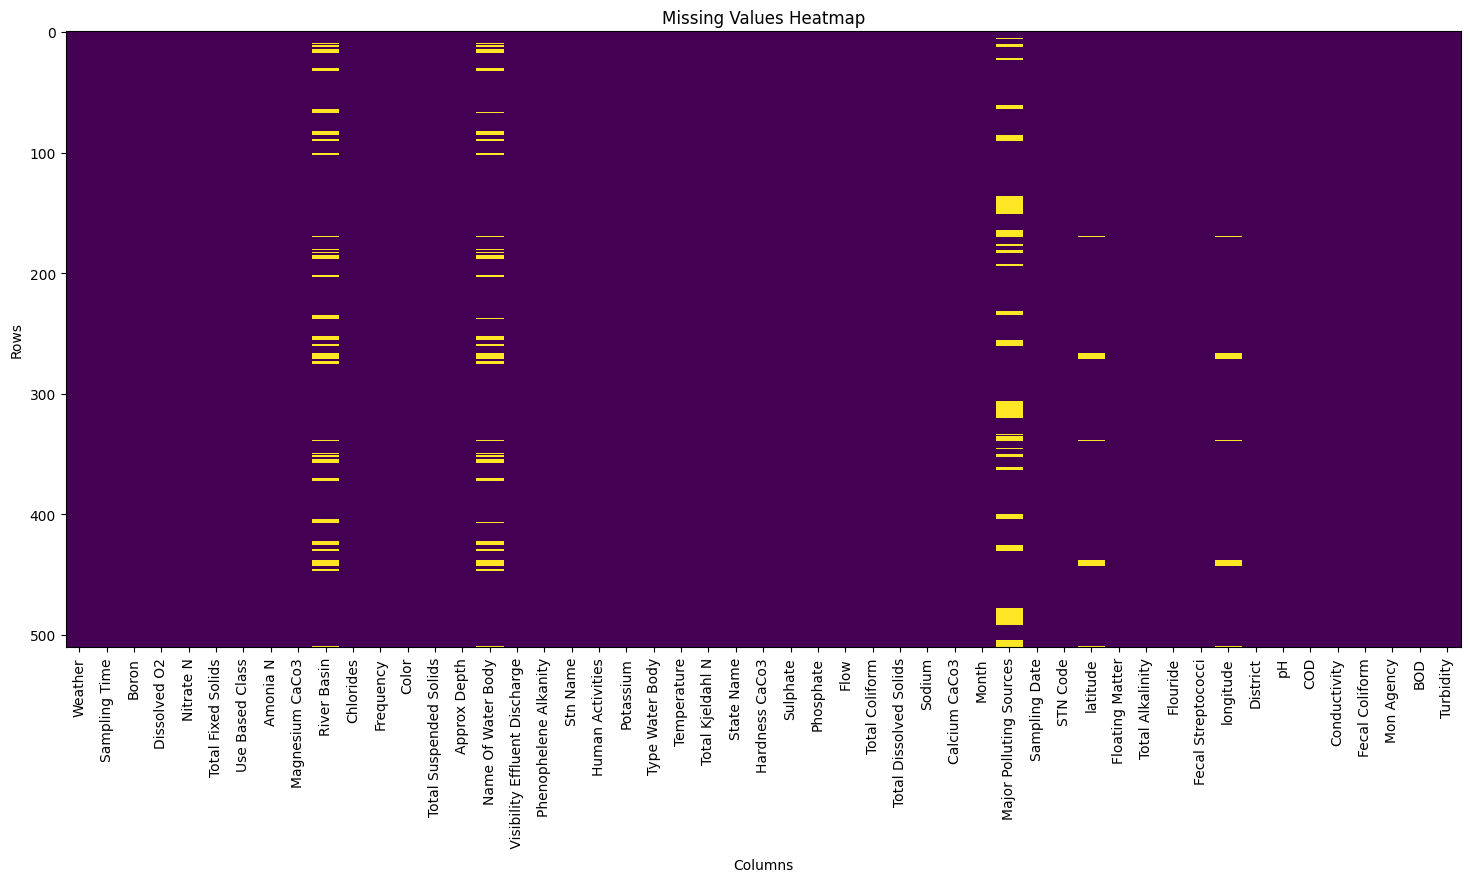

In [34]:
plot_missing_values_heatmap(combined_df)

### Duplication handeling

In [35]:
'''
Purpose:
    Check for duplicate rows in the DataFrame and print the count of duplicates.

Args:
    df (DataFrame): Input DataFrame

Return:
    None
'''
def check_duplicates(df):
    duplicate_count = df.duplicated().sum()
    print(f"Total duplicate rows: {duplicate_count}")


check_duplicates(combined_df)


Total duplicate rows: 0


# **2. Exploratory Data Analysis Plots**

### Chart 1

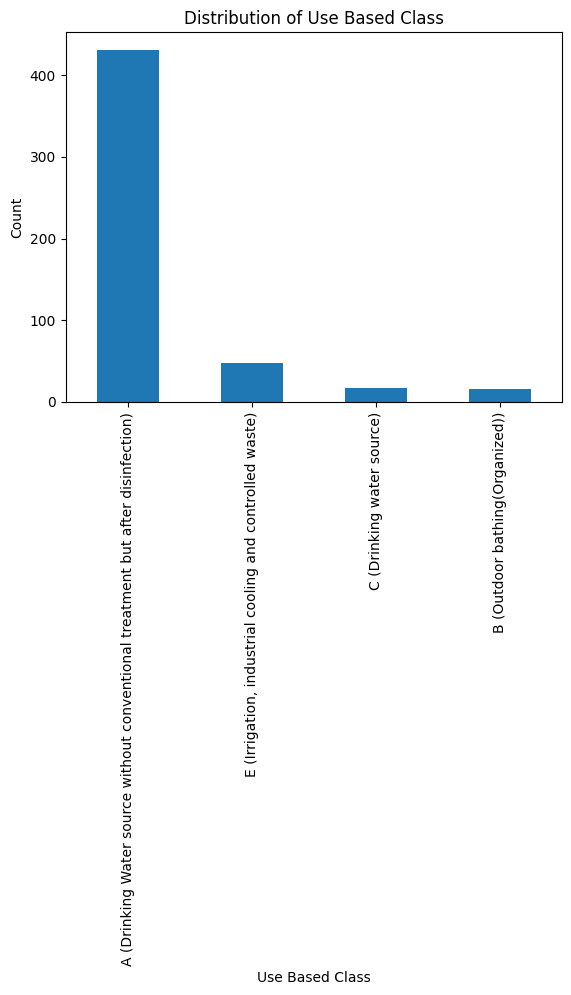

In [36]:
import matplotlib.pyplot as plt

counts = combined_df["Use Based Class"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.xlabel("Use Based Class")
plt.ylabel("Count")
plt.title("Distribution of Use Based Class")
plt.show()


**Plot:** Count Plot – Use Based Class

**Why to choose this plot:**
To understand the distribution of target classes and check whether the dataset is imbalanced before training a machine learning model.

**What info I got:**
Most samples belong to Class A (Drinking water source without conventional treatment but after disinfection), while Classes B, C, and E have much fewer records, indicating strong class imbalance.


### chart 2

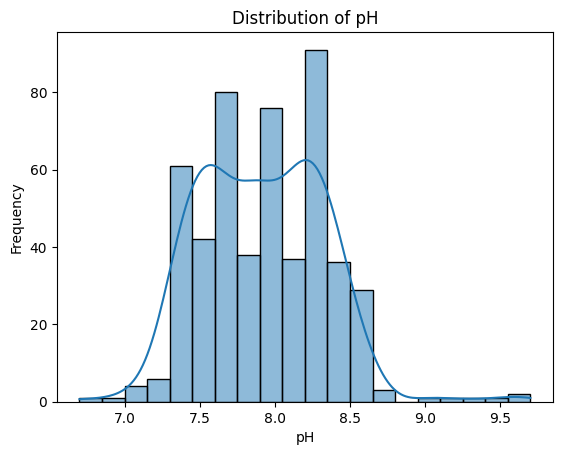

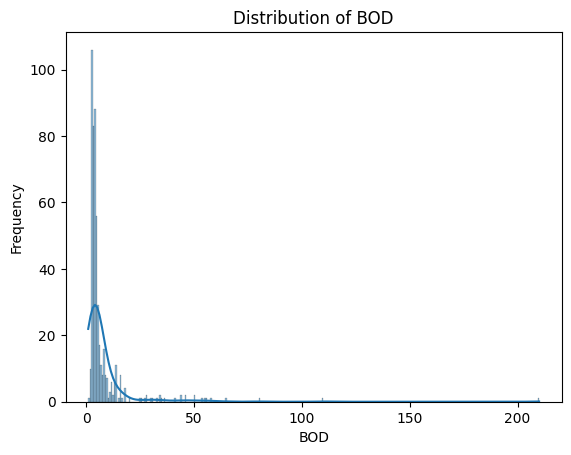

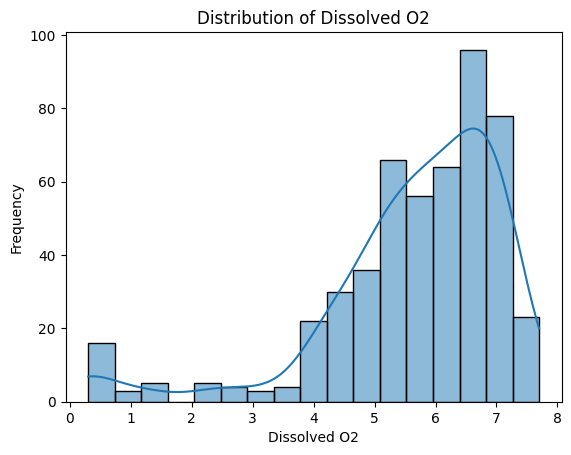

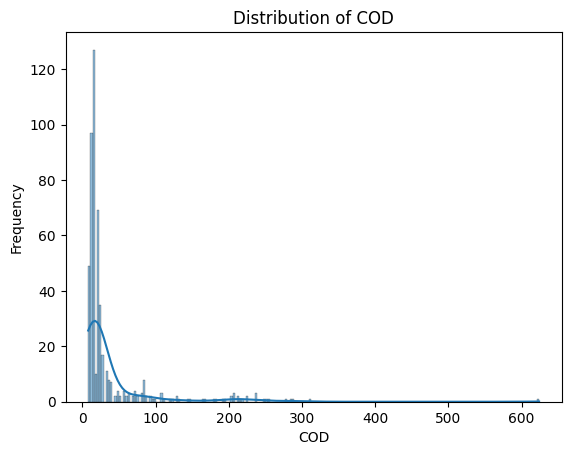

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["pH", "BOD", "Dissolved O2", "COD"]

for col in cols:
    plt.figure()
    sns.histplot(combined_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


Distribution of COD

**Why to choose this plot:**
To understand the spread, skewness, and presence of extreme values in COD before modeling.

**What info I got:**
COD is highly right-skewed with many low values and a few very high outliers, indicating possible need for log transformation or outlier handling.

---

Distribution of Dissolved O2

**Why to choose this plot:**
To examine whether dissolved oxygen follows a normal pattern and detect unusual values.

**What info I got:**
Most values lie between 4 and 7 mg/L with slight skewness, showing relatively stable oxygen levels and fewer extreme outliers.

---

Distribution of BOD

**Why to choose this plot:**
To check skewness and identify extreme pollution cases affecting model learning.

**What info I got:**
BOD is strongly right-skewed with many small values and some very large values, suggesting outlier treatment or transformation is required.

---

Distribution of pH

**Why to choose this plot:**
To observe central tendency and normality of pH values.

**What info I got:**
pH values are concentrated around 7–8.5 and approximately normally distributed, indicating minimal transformation is needed.


### chart 3

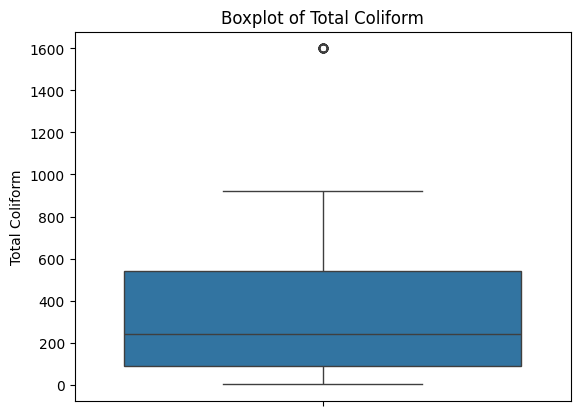

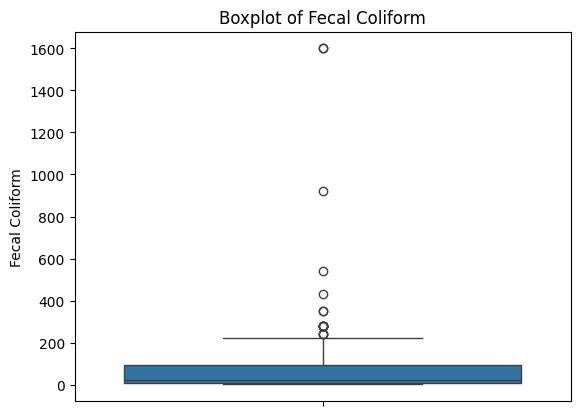

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["Total Coliform", "Fecal Coliform"]

for col in cols:
    plt.figure()
    sns.boxplot(y=combined_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


  Boxplot of Total Coliform

**Why to choose this plot:**
To detect outliers and understand the spread of total coliform levels, which indicate overall bacterial contamination.

**What info I got:**
Most values lie at lower levels, but there are extreme high outliers, showing occasional heavy contamination events that may require outlier handling.

---

  Boxplot of Fecal Coliform

**Why to choose this plot:**
To identify extreme fecal contamination values and check data spread.

**What info I got:**
Fecal coliform values are highly right-skewed with several large outliers, suggesting strong variability and need for transformation or capping.


### chart 4

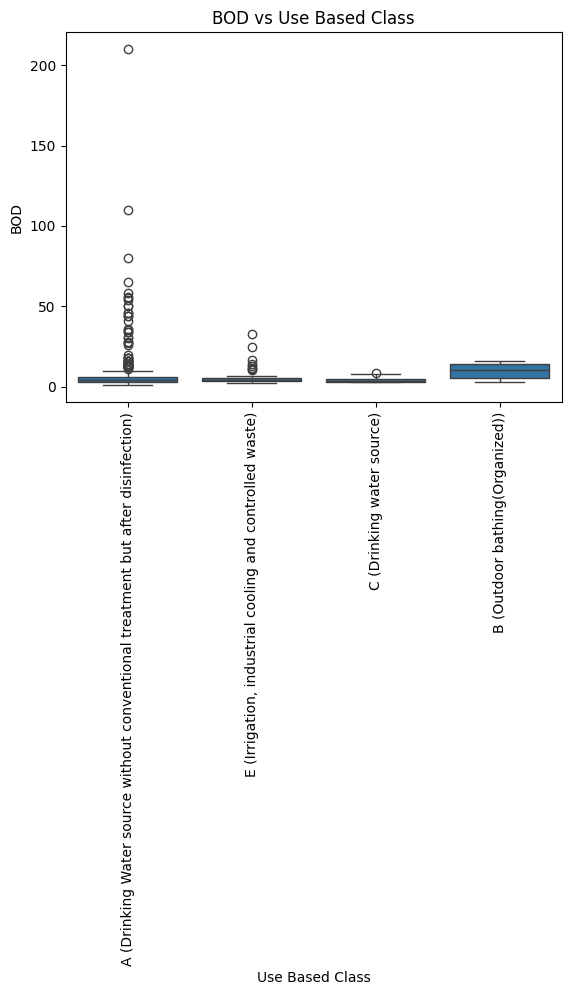

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="Use Based Class", y="BOD", data=combined_df)
plt.title("BOD vs Use Based Class")
plt.xticks(rotation=90)
plt.show()


Box Plot of BOD vs Use Based Class

Why to choose this plot:
To compare how Biochemical Oxygen Demand (BOD) varies across different water use classes and evaluate its ability to differentiate between classes.

What info I got:
BOD distributions differ across classes, with higher median and wider spread for lower-quality classes, indicating that BOD is an important feature for predicting water use classification.

### chart 5

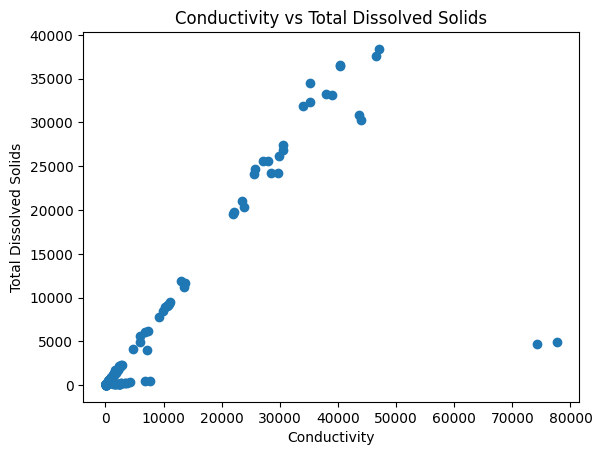

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(combined_df["Conductivity"], combined_df["Total Dissolved Solids"])
plt.xlabel("Conductivity")
plt.ylabel("Total Dissolved Solids")
plt.title("Conductivity vs Total Dissolved Solids")
plt.show()


Scatter Plot of Conductivity vs Total Dissolved Solids

Why to choose this plot:
To check the relationship and correlation between conductivity and total dissolved solids and identify redundancy between features.

What info I got:
There is a strong positive linear relationship between conductivity and total dissolved solids, suggesting that one of these features could be dropped to reduce multicollinearity.

### chart 6

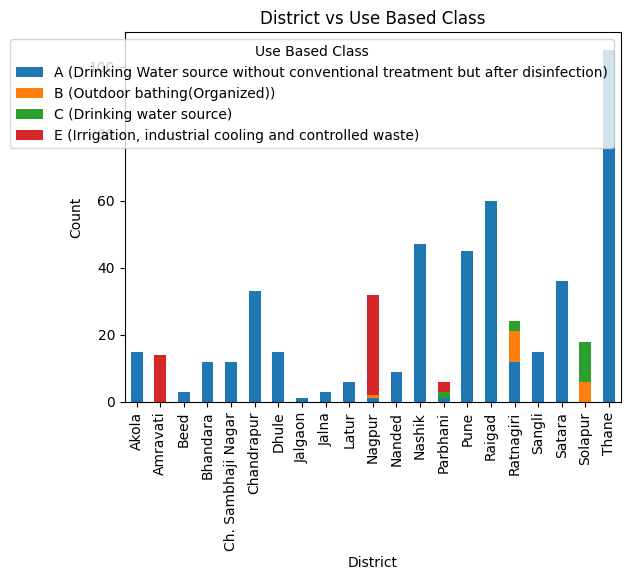

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

cross_tab = pd.crosstab(combined_df["District"], combined_df["Use Based Class"])

cross_tab.plot(kind="bar", stacked=True)
plt.xlabel("District")
plt.ylabel("Count")
plt.title("District vs Use Based Class")
plt.show()


Bar Chart of District vs Use Based Class

Why to choose this plot:
To analyze how water use classes vary across different districts and detect geographic patterns in water quality.

What info I got:
Some districts have a higher concentration of lower-quality classes compared to others, indicating location plays an important role in determining water quality and can be a useful predictive feature.

### chart 7

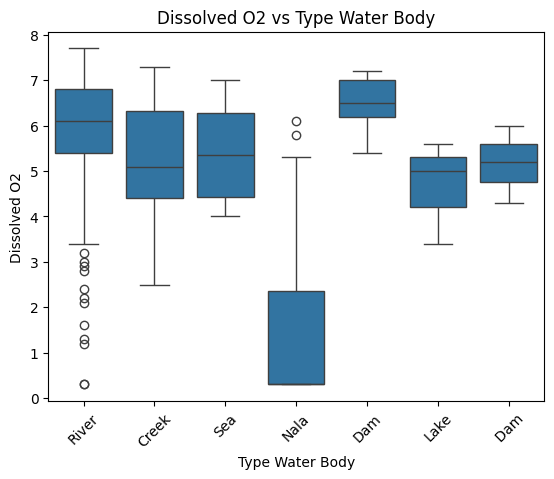

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="Type Water Body", y="Dissolved O2", data=combined_df)
plt.xticks(rotation=45)
plt.title("Dissolved O2 vs Type Water Body")
plt.show()


Box Plot of Dissolved O2 vs Type Water Body

Why to choose this plot:
To compare dissolved oxygen levels across different types of water bodies and understand how water body type influences oxygen availability.

What info I got:
Dams and rivers show higher median dissolved oxygen levels compared to lakes and creeks, indicating that water body type significantly affects oxygen concentration and is a useful categorical feature for modeling.

### chart 8

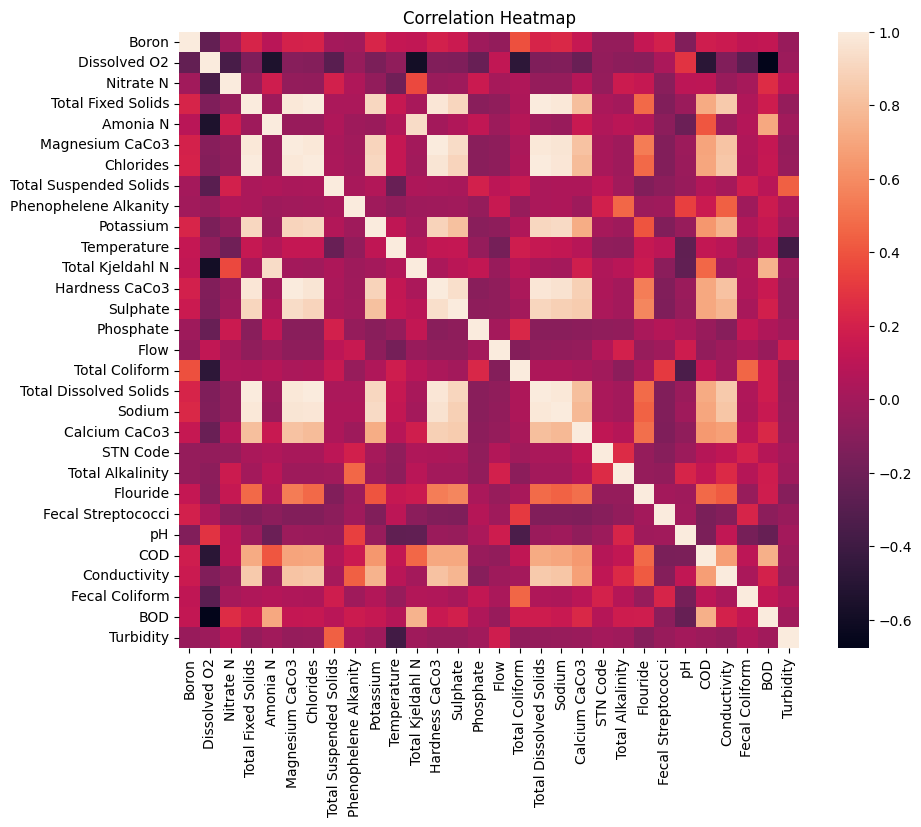

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = combined_df.select_dtypes(include=["float64", "int64"])
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr)
plt.title("Correlation Heatmap")
plt.show()


Correlation Heatmap (Numeric Features)

Why to choose this plot:
To understand relationships between numeric features and detect highly correlated variables that may cause multicollinearity.

What info I got:
Several physicochemical parameters show moderate to strong positive correlations (e.g., conductivity with total dissolved solids, sodium with chlorides), indicating redundancy among some features and guiding feature selection.

### chart 9

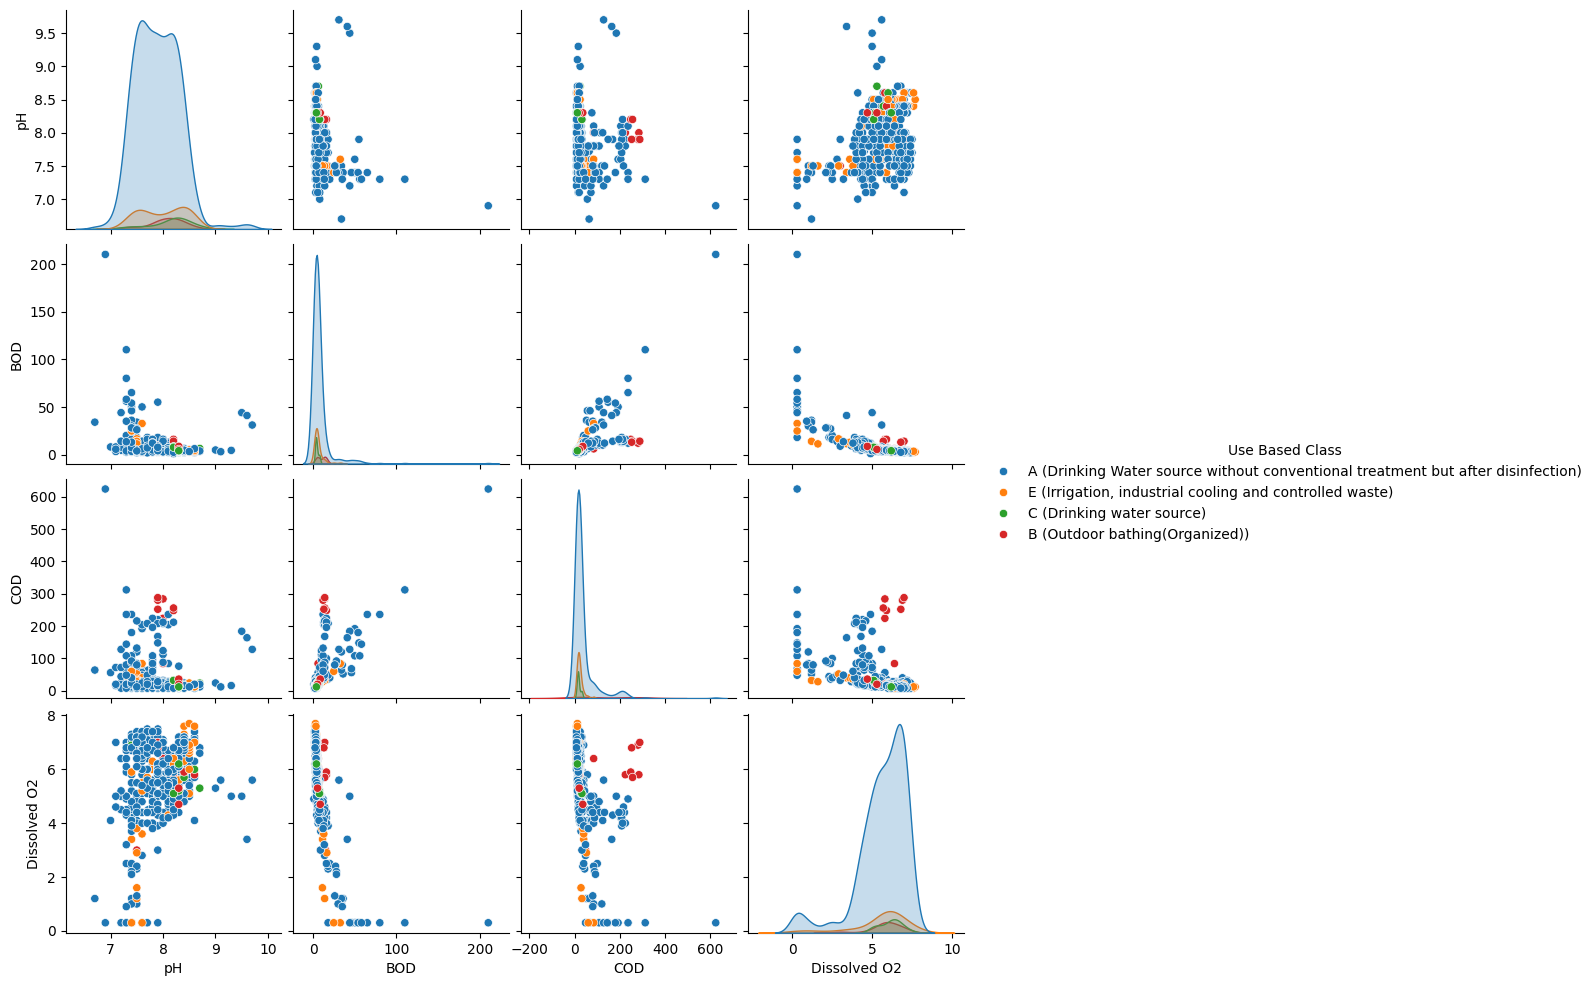

In [44]:
import seaborn as sns

features = ["pH", "BOD", "COD", "Dissolved O2", "Use Based Class"]
sns.pairplot(combined_df[features], hue="Use Based Class")
plt.show()


 Pair Plot (pH, BOD, COD, Dissolved O2 vs Use Based Class)

**Why to choose this plot:**
To visualize relationships between key water quality parameters simultaneously and observe how different use-based classes separate across multiple feature combinations.

**What info I got:**
Some class separation is visible, especially for BOD and COD, while pH and Dissolved O2 show overlapping distributions. This suggests non-linear boundaries and indicates that tree-based models (e.g., Random Forest) may perform better than simple linear models.


### chart 10

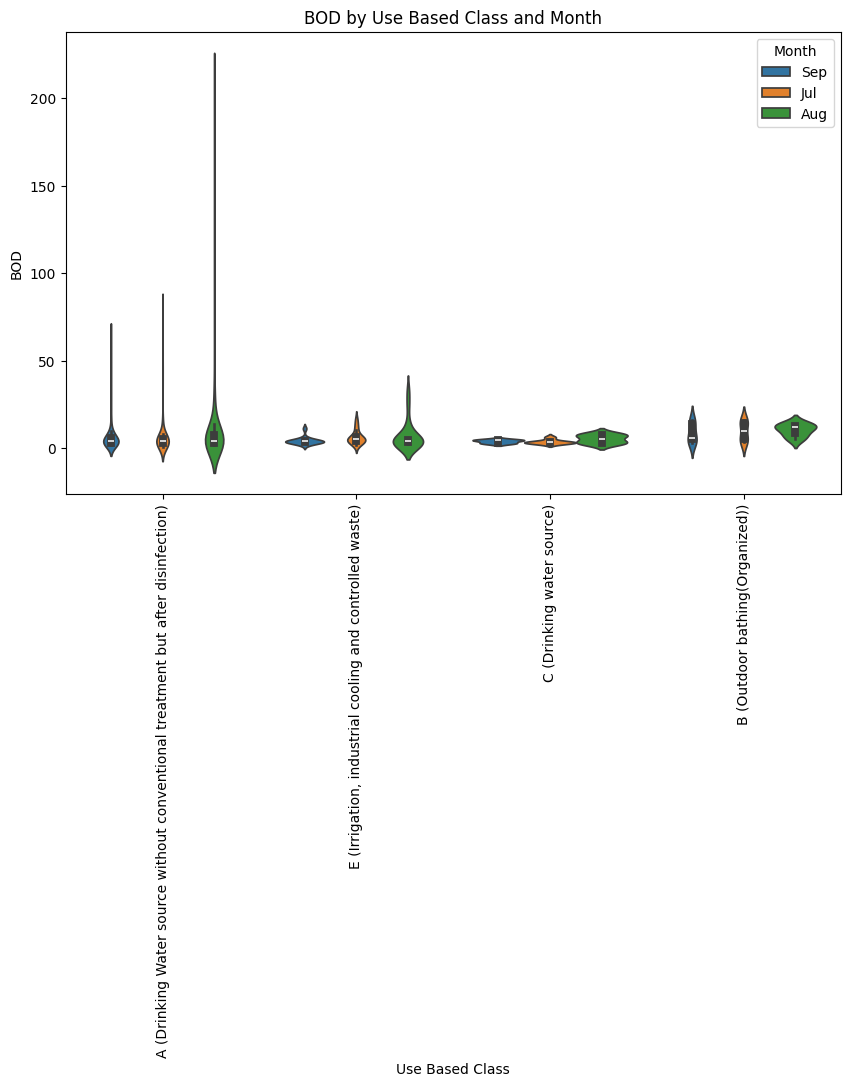

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.violinplot(x="Use Based Class", y="BOD", hue="Month", data=combined_df)
plt.title("BOD by Use Based Class and Month")
plt.xticks(rotation=90)
plt.show()


Violin Plot of BOD by Use Based Class Split by Month

**Why to choose this plot:**
To analyze seasonal variation of BOD within each water use class and understand whether month influences pollution levels.

**What info I got:**
BOD distributions vary slightly across months for the same class, indicating seasonal effects exist. This suggests that `Month` is a meaningful feature and should be included in the machine learning model.


# **3. Feature Engineering**

## Feature Selection Based On EDA

In [46]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 665
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Weather                         511 non-null    object 
 1   Sampling Time                   511 non-null    object 
 2   Boron                           511 non-null    float64
 3   Dissolved O2                    511 non-null    float64
 4   Nitrate N                       511 non-null    float64
 5   Total Fixed Solids              511 non-null    float64
 6   Use Based Class                 511 non-null    object 
 7   Amonia N                        511 non-null    float64
 8   Magnesium CaCo3                 511 non-null    float64
 9   River Basin                     450 non-null    object 
 10  Chlorides                       511 non-null    float64
 11  Frequency                       511 non-null    object 
 12  Color                           511 non-n

In [47]:
'''
Purpose:
    Create a new DataFrame by selecting the final chosen feature columns
    for machine learning and dropping redundant features.

Args:
    df (DataFrame): Input root DataFrame

Return:
    selected_df (DataFrame): DataFrame containing only selected features
'''
def create_selected_feature_df(df):
    selected_columns = [
        "pH",
        "Dissolved O2",
        "BOD",
        "COD",
        "Turbidity",
        "Temperature",
        "Conductivity",
        "Chlorides",
        "Total Dissolved Solids",
        "Hardness CaCo3",
        "Nitrate N",
        # "Total Kjeldahl N",
        "Phosphate",
        "Amonia N",
        "Total Coliform",
        "Fecal Coliform",
        # "Type Water Body",
        "Use Based Class"
    ]

    selected_df = df[selected_columns].copy()

    return selected_df


final_df = create_selected_feature_df(combined_df)




**Feature Selection Rationale for Water Quality Classification**

The objective of this project is to classify water sources into multiple *Use Based Classes* using physicochemical and microbiological parameters. Although the dataset contains a large number of variables, using all features is neither efficient nor beneficial for machine learning model performance. Therefore, a reduced and carefully selected feature set is constructed based on domain knowledge and exploratory data analysis (EDA).

---

1. Importance of Feature Reduction

High-dimensional datasets often introduce noise, redundancy, and multicollinearity, which can:

* Reduce model interpretability
* Increase training time
* Lead to overfitting
* Decrease generalization performance

Selecting fewer but highly informative features improves model stability and predictive power.

---

2. Selection Based on Domain Knowledge

Water quality classification primarily depends on indicators representing:

* Acidity/alkalinity (pH)
* Organic pollution (BOD, COD)
* Oxygen availability (Dissolved O2)
* Nutrient pollution (Nitrate N, Total Kjeldahl N, Phosphate, Amonia N)
* Salinity and mineral content (Conductivity, Chlorides, Total Dissolved Solids)
* Microbial contamination (Total Coliform, Fecal Coliform)
* Physical condition (Turbidity, Temperature)
* Environmental context (Type Water Body)

These parameters are widely accepted in environmental science as strong indicators of water quality.

---

3. Selection Based on Correlation Analysis

Correlation heatmap analysis revealed strong relationships between certain variables:

* Conductivity and Total Dissolved Solids
* Sodium and Chlorides
* Total Suspended Solids and Total Fixed Solids

To avoid redundancy and multicollinearity, only one representative feature from each highly correlated pair is retained.

Kept:

* Conductivity
* Chlorides
* Total Dissolved Solids

Dropped:

* Sodium
* Total Suspended Solids
* Total Fixed Solids

---

4. Selection Based on Exploratory Data Analysis

From histograms, boxplots, scatter plots, and pair plots:

* BOD, COD, Dissolved O2, and pH show meaningful variation across Use Based Classes.
* Bacterial indicators contain strong outliers but remain critical predictors.
* Type Water Body influences dissolved oxygen distribution and indirectly affects water quality.

These findings support retaining these variables in the final feature set.

---

5. Final Selected Features

The final model input consists of the following columns:

* pH
* Dissolved O2
* BOD
* COD
* Turbidity
* Temperature
* Conductivity
* Chlorides
* Total Dissolved Solids
* Hardness CaCo3
* Nitrate N
* Total Kjeldahl N
* Phosphate
* Amonia N
* Total Coliform
* Fecal Coliform
* Type Water Body

Target Variable:

* Use Based Class

---

6. Expected Benefits

This reduced feature set:

* Minimizes noise and redundancy
* Improves model training speed
* Enhances generalization capability
* Preserves interpretability
* Aligns with environmental science standards

Thus, the selected features provide an optimal balance between model simplicity and predictive strength for water quality classification.


## Encoding

In [48]:
# #  16  Type Water Body         511 non-null    object
# #  17  Use Based Class         511 non-null    object

# final_df['Type Water Body'].unique()

In [49]:
final_df['Use Based Class'].unique()

array(['A (Drinking Water source without conventional treatment but after disinfection)',
       'E (Irrigation, industrial cooling and controlled waste)',
       'C (Drinking water source)', 'B (Outdoor bathing(Organized))'],
      dtype=object)

In [50]:
'''
Purpose:
    Apply value-based encoding for target column and clean + encode
    Type Water Body column.

Args:
    df (DataFrame): Input DataFrame

Return:
    updated_df (DataFrame): Encoded DataFrame
'''
def apply_value_encodings(df):
    updated_df = df.copy()

    updated_df["Use Based Class"] = updated_df["Use Based Class"].map({
        "A (Drinking Water source without conventional treatment but after disinfection)": 0,
        "B (Outdoor bathing(Organized))": 1,
        "C (Drinking water source)": 2,
        "E (Irrigation, industrial cooling and controlled waste)": 3
    })

    # updated_df["Type Water Body"] = updated_df["Type Water Body"].replace({
    #     " Dam": "Dam"
    # })

    # updated_df["Type Water Body"] = updated_df["Type Water Body"].map({
    #     "River": 0,
    #     "Creek": 1,
    #     "Sea": 2,
    #     "Nala": 3,
    #     "Dam": 4,
    #     "Lake": 5
    # })

    return updated_df


final_df = apply_value_encodings(final_df)


## Feature Selection

In [51]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511 entries, 0 to 665
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pH                      511 non-null    float64
 1   Dissolved O2            511 non-null    float64
 2   BOD                     511 non-null    float64
 3   COD                     511 non-null    float64
 4   Turbidity               511 non-null    float64
 5   Temperature             511 non-null    float64
 6   Conductivity            511 non-null    float64
 7   Chlorides               511 non-null    float64
 8   Total Dissolved Solids  511 non-null    float64
 9   Hardness CaCo3          511 non-null    float64
 10  Nitrate N               511 non-null    float64
 11  Phosphate               511 non-null    float64
 12  Amonia N                511 non-null    float64
 13  Total Coliform          511 non-null    float64
 14  Fecal Coliform          511 non-null    float64

In [52]:
'''
Purpose:
    Calculate Variance Inflation Factor (VIF) for each numeric feature
    and return results ordered from highest to lowest VIF.

Args:
    df (DataFrame): Input DataFrame containing numeric features

Return:
    vif_df (DataFrame): VIF table sorted in descending order
'''
def calculate_vif(df):
    import pandas as pd
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    X = df.select_dtypes(include=["float64", "int64"])

    vif_data = []
    for i in range(X.shape[1]):
        vif_data.append(
            {
                "Feature": X.columns[i],
                "VIF": variance_inflation_factor(X.values, i)
            }
        )

    vif_df = pd.DataFrame(vif_data)
    vif_df = vif_df.sort_values(by="VIF", ascending=False).reset_index(drop=True)

    return vif_df


vif_df = calculate_vif(final_df)
vif_df


,Feature,VIF
0,Total Dissolved Solids,162.746433
1,Chlorides,121.977885
2,pH,109.747830
3,Temperature,62.915043
4,Dissolved O2,39.852242
5,Hardness CaCo3,30.153700
6,COD,18.892000
7,BOD,12.968167
8,Conductivity,4.555585
9,Total Coliform,3.144744


## Split train / test

In [53]:
'''
Purpose:
    Split dataset into training and testing sets with stratified distribution.

Args:
    df (DataFrame): Input DataFrame
    target_column (str): Name of target column
    test_size (float): Proportion of test data

Return:
    X_train, X_test, y_train, y_test
'''
def stratified_train_test_split(df, target_column, test_size=0.3):
    from sklearn.model_selection import train_test_split

    X = df.drop(columns=[target_column])
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = stratified_train_test_split(
    final_df,
    "Use Based Class",
    0.3
)


# **4. Machine Learning Model Training**

| Model                            | Train F1 Score | Test F1 Score | Train Confusion Matrix Behavior                              | Test Confusion Matrix Behavior                                    |
| -------------------------------- | -------------- | ------------- | ------------------------------------------------------------ | ----------------------------------------------------------------- |
| **SVM (Scaled)**                 | 0.6809         | 0.6799        | Moderate diagonal dominance, heavy confusion between A and C | Similar confusion between A and C, weak minority class separation |
| **Logistic Regression (Scaled)** | 0.5640         | 0.5690        | Weak diagonal, many misclassifications across classes        | Poor separation of classes, struggles with non-linearity          |
| **Random Forest (Tuned)**        | 0.9918         | 0.8425        | Almost perfect diagonal → strong memorization                | Good diagonal dominance, some confusion in minority classes       |
| **LightGBM (Tuned)**             | 1.0000         | 0.8750        | Perfect diagonal → complete training fit                     | Strong diagonal dominance, best minority class recognition        |


## Random Forest

Train F1 Score: 1.0
Test F1 Score: 0.8659039373325086


<Figure size 640x480 with 0 Axes>

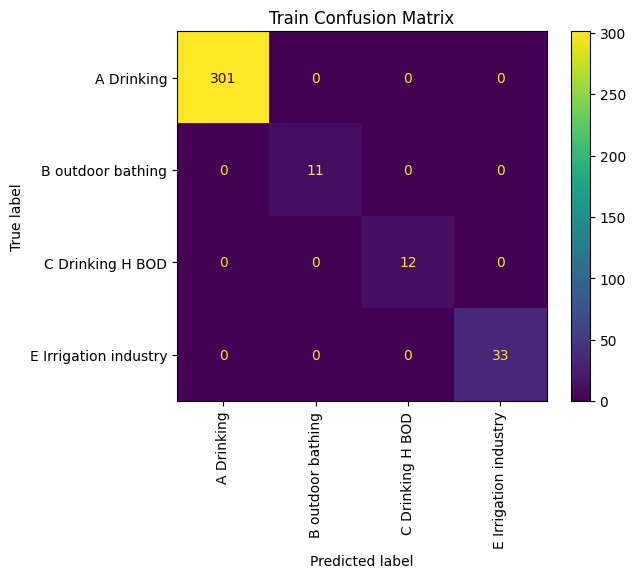

<Figure size 640x480 with 0 Axes>

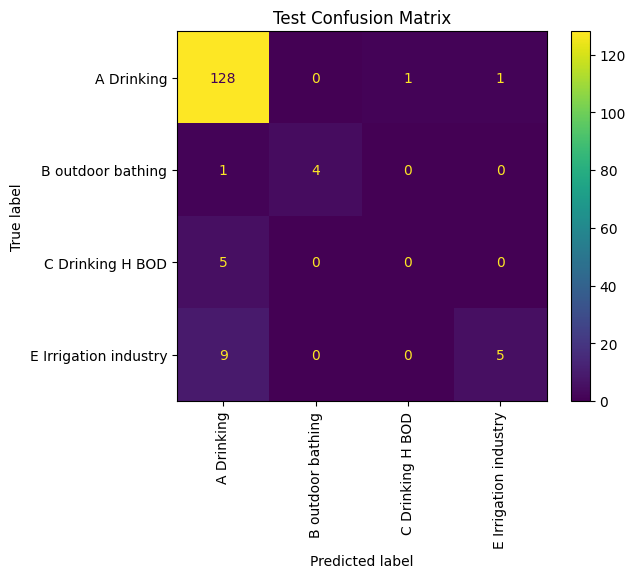

In [54]:
'''
Purpose:
    Train a baseline Random Forest classifier and display confusion matrix
    plots with class names and F1-score for both training and testing datasets.

Args:
    X_train (DataFrame): Training features
    X_test (DataFrame): Testing features
    y_train (Series): Training labels
    y_test (Series): Testing labels

Return:
    model (RandomForestClassifier): Trained model
'''
def train_random_forest_and_evaluate(X_train, X_test, y_train, y_test):
    import matplotlib.pyplot as plt
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

    class_labels = [
        "A Drinking",
        "B outdoor bathing",
        "C Drinking H BOD",
        "E Irrigation industry"
    ]

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("Train F1 Score:", f1_score(y_train, y_train_pred, average="weighted"))
    print("Test F1 Score:", f1_score(y_test, y_test_pred, average="weighted"))

    train_cm = confusion_matrix(y_train, y_train_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)

    plt.figure()
    ConfusionMatrixDisplay(train_cm, display_labels=class_labels).plot()
    plt.title("Train Confusion Matrix")
    plt.xticks(rotation=90)
    plt.show()

    plt.figure()
    ConfusionMatrixDisplay(test_cm, display_labels=class_labels).plot()
    plt.title("Test Confusion Matrix")
    plt.xticks(rotation=90)
    plt.show()

    return model


rf_model = train_random_forest_and_evaluate(
    X_train,
    X_test,
    y_train,
    y_test
)


### RandomCV hyperparameter optimization

In [55]:
'''
Purpose:
    Perform RandomizedSearchCV to tune Random Forest hyperparameters
    with class imbalance handling and F1-score optimization.

Args:
    X_train (DataFrame): Training features
    y_train (Series): Training labels

Return:
    best_model (RandomForestClassifier): Best tuned model
'''
def randomcv_random_forest_f1_imbalance(X_train, y_train):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import RandomizedSearchCV

    param_grid = {
        "n_estimators": [200, 300, 400, 500],
        "max_depth": [8, 10, 12, 15, 20],
        "min_samples_split": [5, 10, 15],
        "min_samples_leaf": [2, 5, 10],
        "max_features": ["sqrt", "log2"]
    }

    rf = RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    )

    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_grid,
        n_iter=30,
        scoring="f1_weighted",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    print("Best Parameters:")
    print(random_search.best_params_)

    return random_search.best_estimator_


best_rf_model = randomcv_random_forest_f1_imbalance(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 8}


Train F1 Score: 0.9917582769480008
Test F1 Score: 0.8738007300222445


<Figure size 640x480 with 0 Axes>

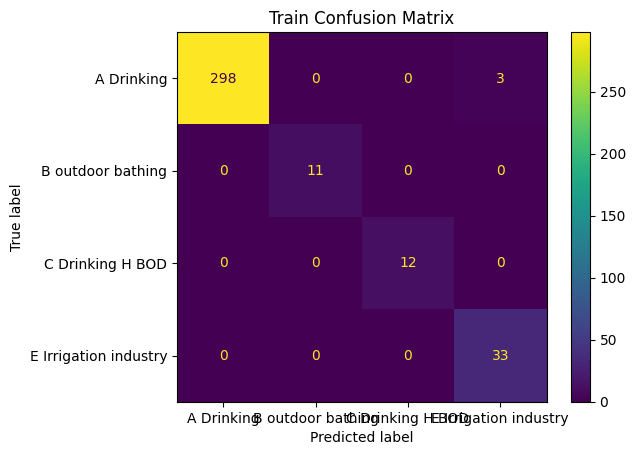

<Figure size 640x480 with 0 Axes>

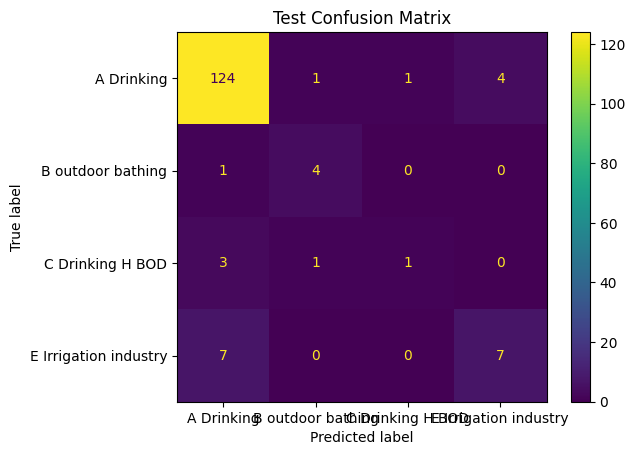

In [56]:
'''
Purpose:
    Train Random Forest model using user-provided hyperparameters
    and evaluate with confusion matrix plots and F1-score.

Args:
    X_train (DataFrame): Training features
    X_test (DataFrame): Testing features
    y_train (Series): Training labels
    y_test (Series): Testing labels
    params (dict): Dictionary of Random Forest hyperparameters

Return:
    model (RandomForestClassifier): Trained model
'''
def train_rf_with_given_params(X_train, X_test, y_train, y_test, params):
    import matplotlib.pyplot as plt
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

    class_labels = [
        "A Drinking",
        "B outdoor bathing",
        "C Drinking H BOD",
        "E Irrigation industry"
    ]

    model = RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        **params
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("Train F1 Score:", f1_score(y_train, y_train_pred, average="weighted"))
    print("Test F1 Score:", f1_score(y_test, y_test_pred, average="weighted"))

    train_cm = confusion_matrix(y_train, y_train_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)

    plt.figure()
    ConfusionMatrixDisplay(train_cm, display_labels=class_labels).plot()
    plt.title("Train Confusion Matrix")
    plt.show()

    plt.figure()
    ConfusionMatrixDisplay(test_cm, display_labels=class_labels).plot()
    plt.title("Test Confusion Matrix")
    plt.show()

    return model


params = {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 8}

final_rf_model = train_rf_with_given_params(
    X_train,
    X_test,
    y_train,
    y_test,
    params
)


## LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 927
[LightGBM] [Info] Number of data points in the train set: 357, number of used features: 15
[LightGBM] [Info] Start training from score -0.170626
[LightGBM] [Info] Start training from score -3.479841
[LightGBM] [Info] Start training from score -3.392829
[LightGBM] [Info] Start training from score -2.381228
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

<Figure size 640x480 with 0 Axes>

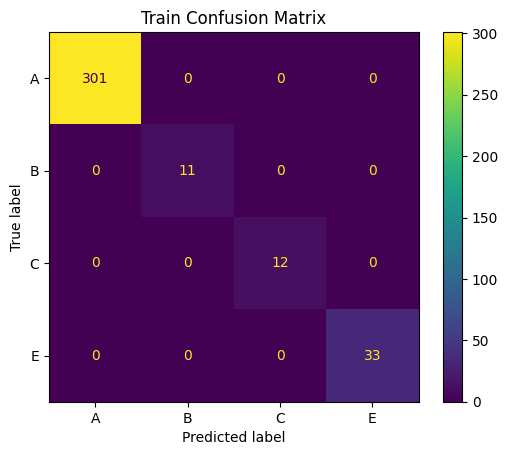

<Figure size 640x480 with 0 Axes>

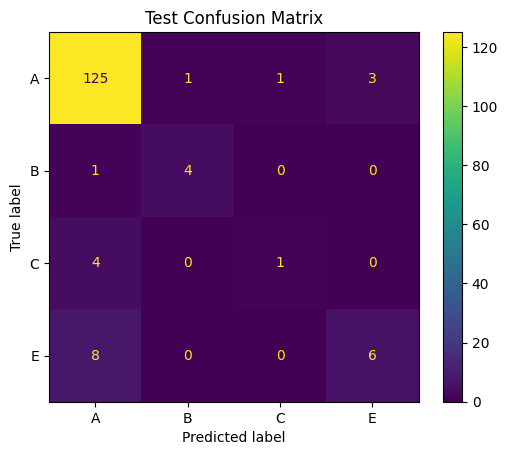

In [57]:
'''
Purpose:
    Train a baseline LightGBM classifier and display confusion matrix
    plots and F1-score for both training and testing datasets.

Args:
    X_train (DataFrame): Training features
    X_test (DataFrame): Testing features
    y_train (Series): Training labels
    y_test (Series): Testing labels

Return:
    model (LGBMClassifier): Trained LightGBM model
'''
def train_lightgbm_baseline(X_train, X_test, y_train, y_test):
    import matplotlib.pyplot as plt
    from lightgbm import LGBMClassifier
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

    class_labels = ["A", "B", "C", "E"]

    model = LGBMClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("Train F1 Score:", f1_score(y_train, y_train_pred, average="weighted"))
    print("Test F1 Score:", f1_score(y_test, y_test_pred, average="weighted"))

    train_cm = confusion_matrix(y_train, y_train_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)

    plt.figure()
    ConfusionMatrixDisplay(train_cm, display_labels=class_labels).plot()
    plt.title("Train Confusion Matrix")
    plt.show()

    plt.figure()
    ConfusionMatrixDisplay(test_cm, display_labels=class_labels).plot()
    plt.title("Test Confusion Matrix")
    plt.show()

    return model


lgbm_model = train_lightgbm_baseline(
    X_train,
    X_test,
    y_train,
    y_test
)


### RandomCV hyperparameter optimization

In [58]:
'''
Purpose:
    Perform RandomizedSearchCV for LightGBM to reduce overfitting,
    handle class imbalance, and optimize F1-score.

Args:
    X_train (DataFrame): Training features
    y_train (Series): Training labels

Return:
    best_model (LGBMClassifier): Best tuned LightGBM model
'''
def randomcv_lightgbm_f1_imbalance(X_train, y_train):
    from lightgbm import LGBMClassifier
    from sklearn.model_selection import RandomizedSearchCV

    param_grid = {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [5, 8, 10, 12, 15],
        "learning_rate": [0.01, 0.05, 0.1],
        "num_leaves": [15, 31, 50, 80],
        "min_child_samples": [5, 10, 20, 40],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0]
    }

    lgbm = LGBMClassifier(
        random_state=42,
        class_weight="balanced"
    )

    random_search = RandomizedSearchCV(
        estimator=lgbm,
        param_distributions=param_grid,
        n_iter=30,
        scoring="f1_weighted",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    print("Best Parameters:")
    print(random_search.best_params_)

    return random_search.best_estimator_


best_lgbm_model = randomcv_lightgbm_f1_imbalance(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 927
[LightGBM] [Info] Number of data points in the train set: 357, number of used features: 15
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 927
[LightGBM] [Info] Number of data points in the train set: 357, number of used features: 15
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

<Figure size 640x480 with 0 Axes>

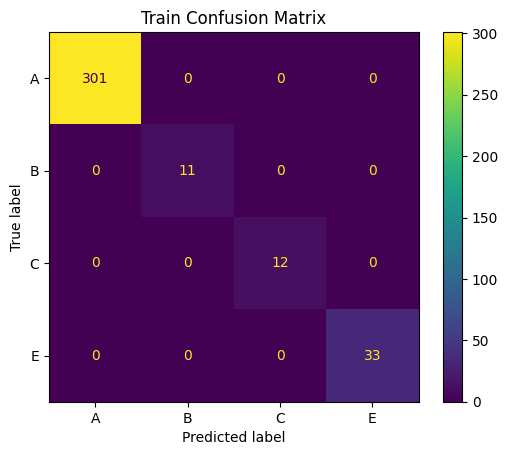

<Figure size 640x480 with 0 Axes>

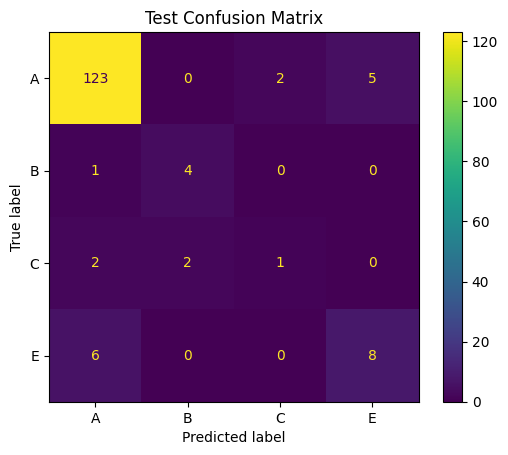

Model saved as water_quality_lgbm_model.joblib


In [59]:
'''
Purpose:
    Train LightGBM model using given hyperparameters and evaluate with
    confusion matrix plots and F1-score.

Args:
    X_train (DataFrame): Training features
    X_test (DataFrame): Testing features
    y_train (Series): Training labels
    y_test (Series): Testing labels
    params (dict): Dictionary of LightGBM hyperparameters

Return:
    model (LGBMClassifier): Trained model
'''
def train_lgbm_with_given_params(X_train, X_test, y_train, y_test, params):
    import matplotlib.pyplot as plt
    from lightgbm import LGBMClassifier
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

    class_labels = ["A", "B", "C", "E"]

    model = LGBMClassifier(
        random_state=42,
        class_weight="balanced",
        **params
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("Train F1 Score:", f1_score(y_train, y_train_pred, average="weighted"))
    print("Test F1 Score:", f1_score(y_test, y_test_pred, average="weighted"))

    train_cm = confusion_matrix(y_train, y_train_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)

    plt.figure()
    ConfusionMatrixDisplay(train_cm, display_labels=class_labels).plot()
    plt.title("Train Confusion Matrix")
    plt.show()

    plt.figure()
    ConfusionMatrixDisplay(test_cm, display_labels=class_labels).plot()
    plt.title("Test Confusion Matrix")
    plt.show()

    return model


params = {
    "subsample": 0.8,
    "num_leaves": 80,
    "n_estimators": 200,
    "min_child_samples": 40,
    "max_depth": 10,
    "learning_rate": 0.05,
    "colsample_bytree": 1.0
}

final_lgbm_model = train_lgbm_with_given_params(
    X_train,
    X_test,
    y_train,
    y_test,
    params
)
'''
Purpose:
    Save trained model as a Joblib file for later reuse.

Args:
    model: Trained machine learning model
    file_name (str): Name of the output file

Return:
    None
'''
def save_model_joblib(model, file_name):
    import joblib
    joblib.dump(model, file_name)
    print(f"Model saved as {file_name}")


save_model_joblib(final_lgbm_model, "water_quality_lgbm_model.joblib")


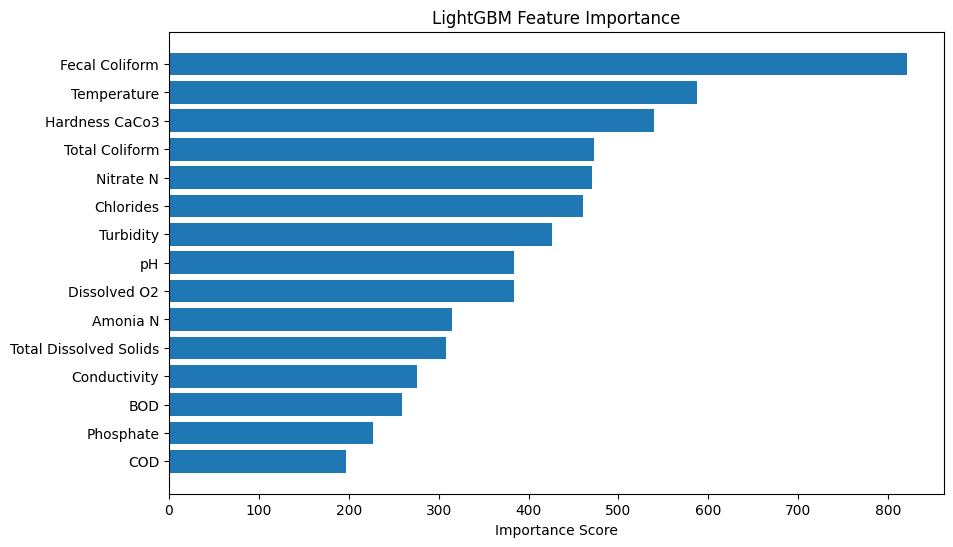

,Feature,Importance
14,Fecal Coliform,821
5,Temperature,587
9,Hardness CaCo3,540
13,Total Coliform,473
10,Nitrate N,470
7,Chlorides,460
4,Turbidity,426
0,pH,384
1,Dissolved O2,384
12,Amonia N,315


In [60]:
'''
Purpose:
    Extract and visualize feature importance from trained LightGBM model.

Args:
    model (LGBMClassifier): Trained LightGBM model
    feature_names (list): List of feature column names

Return:
    importance_df (DataFrame): Feature importance table sorted descending
'''
def plot_lgbm_feature_importance(model, feature_names):
    import pandas as pd
    import matplotlib.pyplot as plt

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,6))
    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )
    plt.gca().invert_yaxis()
    plt.xlabel("Importance Score")
    plt.title("LightGBM Feature Importance")
    plt.show()

    return importance_df


importance_df = plot_lgbm_feature_importance(
    final_lgbm_model,
    X_train.columns.tolist()
)

importance_df


# **5. Artifacts Handling**

In [61]:
for i,col in enumerate(X_train.columns):
  print(i+1,col)

1 pH
2 Dissolved O2
3 BOD
4 COD
5 Turbidity
6 Temperature
7 Conductivity
8 Chlorides
9 Total Dissolved Solids
10 Hardness CaCo3
11 Nitrate N
12 Phosphate
13 Amonia N
14 Total Coliform
15 Fecal Coliform


In [62]:
X_train.iloc[0:2,:]

,pH,Dissolved O2,BOD,COD,Turbidity,Temperature,Conductivity,Chlorides,Total Dissolved Solids,Hardness CaCo3,Nitrate N,Phosphate,Amonia N,Total Coliform,Fecal Coliform
59,7.5,6.9,3.6,12.0,1.0,30.0,260.0,32.49,221.0,82.0,0.43,0.2,1.97,130.0,14.0
122,7.9,5.8,5.0,20.0,450.0,20.0,308.0,29.99,251.0,158.6,2.48,0.2,0.62,140.0,70.0
